In [ ]:
import os
import warnings
import logging
import datetime
import csv
import pickle

# Numerical and data
import numpy as np
import pandas as pd

# Excel (.xlsx)
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors

# Preprocessing and metrics
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

# TensorFlow / Keras (PINN)
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import KFold

# TF configuration (silence logs)
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel(logging.ERROR)

import os, json, datetime
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout,
                                     Lambda, Concatenate, Layer)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import KFold
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment

In [ ]:
file_path = r".\Data\Datosbiomasa _Limpios.xlsx"
df_new = pd.read_excel(file_path)

In [ ]:
df_initial = df_new
df_initial.info()

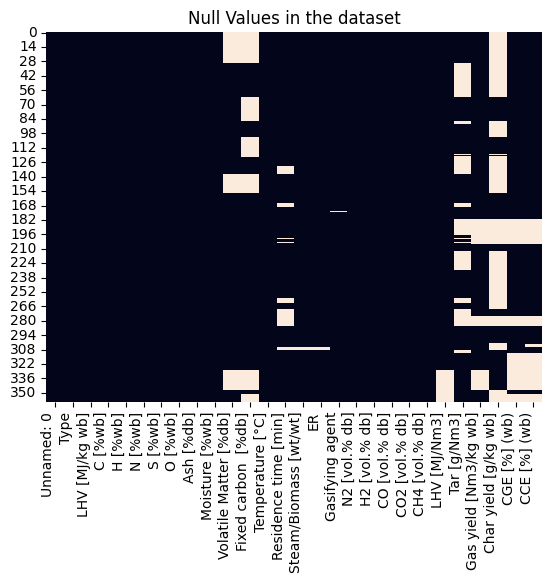

In [ ]:
sns.heatmap(df_initial.isnull(), cbar=False)
plt.title('Null Values in the dataset')
plt.xticks(rotation=90, ha='right')
plt.show()

In [6]:
df_inicial1=df_inicial

In [ ]:
df_initial1 = df_initial
df_initial1.describe()

,Unnamed: 0,LHV [MJ/kg wb],C [%wb],H [%wb],N [%wb],S [%wb],O [%wb],Ash [%db],Moisture [%wb],Volatile Matter [%db],...,H2 [vol.% db],CO [vol.% db],CO2 [vol.% db],CH4 [vol.% db],LHV [MJ/Nm3],Tar [g/Nm3],Gas yield [Nm3/kg wb],Char yield [g/kg wb],CGE [%] (wb),CCE [%] (wb)
count,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,291.000000,...,359.000000,359.000000,359.000000,359.000000,328.000000,240.000000,305.000000,135.000000,282.000000,279.000000
mean,180.030641,18.464252,43.662098,5.753414,1.230481,0.420008,33.254627,6.942512,8.371031,77.648622,...,33.374955,31.228664,26.781133,8.615248,7.489891,26.990716,1.675703,73.361145,60.990222,70.577728
std,103.830258,6.195487,11.388950,1.987790,2.719048,1.095336,10.553844,11.283052,5.308375,8.858631,...,15.980565,11.965375,12.086185,5.412478,3.627736,43.385989,0.970076,70.120351,20.774985,17.558087
min,1.000000,11.500000,23.911875,2.592698,0.000000,0.000000,0.000000,0.270000,0.000000,56.000000,...,7.290450,0.000000,0.000000,0.000000,1.300000,0.000000,0.100753,3.600000,16.702739,20.610000
25%,90.500000,15.061023,38.001362,4.889344,0.137934,0.009250,30.370915,0.551876,6.300000,75.321394,...,22.753822,22.564103,18.669859,5.346022,4.300000,6.046888,1.030000,14.535000,45.193418,59.062332
50%,180.000000,18.100000,44.420739,5.435136,0.336870,0.091565,37.803012,1.950000,8.000000,80.983607,...,30.228392,33.160622,25.559105,7.772021,6.450000,13.664719,1.490000,58.695000,58.501951,72.800000
75%,269.500000,19.300000,46.474439,5.913668,0.900000,0.431731,39.990667,5.930000,9.400000,83.500000,...,42.870000,39.176281,35.695418,10.533513,11.231348,31.292500,2.000000,102.445000,72.065041,82.000000
max,360.000000,42.900000,85.000000,14.000000,13.086220,5.360300,45.996148,44.000000,27.000000,89.110070,...,100.000000,78.734097,62.389381,33.121019,15.595450,364.000000,6.187500,301.520000,122.866258,126.894029


In [ ]:
list(df_initial1.columns)


['Unnamed: 0',
 'Type',
 'LHV [MJ/kg wb]',
 'C [%wb]',
 'H [%wb]',
 'N [%wb]',
 'S [%wb]',
 'O [%wb]',
 'Ash [%db]',
 'Moisture [%wb]',
 'Volatile Matter [%db]',
 'Fixed carbon  [%db]',
 'Temperature [°C]',
 'Residence time [min]',
 'Steam/Biomass [wt/wt]',
 'ER',
 'Gasifying agent',
 'N2 [vol.% db]',
 'H2 [vol.% db]',
 'CO [vol.% db]',
 'CO2 [vol.% db]',
 'CH4 [vol.% db]',
 'LHV [MJ/Nm3]',
 'Tar [g/Nm3]',
 'Gas yield [Nm3/kg wb]',
 'Char yield [g/kg wb]',
 'CGE [%] (wb)',
 'CCE [%] (wb)']

In [ ]:
text_cols = ['Type', 'Gasifying agent']
df_initial1 = df_initial1.replace('-', pd.NA)

numeric_cols = df_initial1.columns.difference(text_cols)

df_initial1[numeric_cols] = df_initial1[numeric_cols].apply(
    pd.to_numeric, errors='coerce')

In [ ]:

# CONSTANTS
X_C_CHAR           = 0.85
X_C_TAR            = 0.87
MOLAR_MASS_C       = 12.011
MOLAR_VOLUME       = 22.4
GAS_DENSITY        = 1.15
DEFAULT_ER         = 0.25
DEFAULT_SB         = 0.0
STOICH_AIR_DEFAULT = 5.12

MM_C_ST     = 12.011
MM_H_ST     = 1.008
MM_O_ST     = 15.999
MM_S_ST     = 32.065
MM_O2_ST    = 32.0
O2_FRAC_AIR = 0.232

C_LHV    = 'LHV [MJ/Nm3]'
C_LHV_BW = 'LHV [MJ/kg wb]'
C_GY     = 'Gas yield [Nm3/kg wb]'
C_CGE    = 'CGE [%] (wb)'
C_CCE    = 'CCE [%] (wb)'
C_CY     = 'Char yield [g/kg wb]'
C_TAR    = 'Tar [g/Nm3]'
C_CO     = 'CO [vol.% db]'
C_CO2    = 'CO2 [vol.% db]'
C_CH4    = 'CH4 [vol.% db]'
C_H2     = 'H2 [vol.% db]'
C_C2     = 'C2Hn [vol.% db]'
C_N2     = 'N2 [vol.% db]'
C_ER     = 'ER'
C_SB     = 'Steam/Biomass [wt/wt]'
C_C      = 'C [%wb]'
C_H      = 'H [%wb]'
C_O      = 'O [%wb]'
C_N      = 'N [%wb]'
C_S      = 'S [%wb]'
C_RT     = 'Residence time [min]'
C_AGENT  = 'Gasifying agent'

CY_MAX_G_KG = 1000.0
BALANCE_TOL = 0.15


# INPUT CLEANING
def clean_inputs(df_raw):

    df = df_raw.copy()
    n_before = len(df)

    df[C_AGENT] = df[C_AGENT].astype(str).str.lower().str.strip()

    no_negative_cols = [C_LHV, C_TAR, C_GY, C_CY, C_H2, C_CO, C_CO2, C_CH4, C_C2, C_RT]
    for col in no_negative_cols:
        if col in df.columns:
            df.loc[df[col] < 0, col] = np.nan

    for col in [C_H2, C_CO, C_CO2, C_CH4]:
        if col in df.columns:
            df.loc[df[col] == 0, col] = np.nan

    if C_RT in df.columns:
        df.loc[df[C_RT] == 0, C_RT] = np.nan

    bad_h2 = (df[C_H2] == 100) & df[[C_CO, C_CO2, C_CH4]].isna().all(axis=1)
    df = df.loc[~bad_h2]

    bad_o = df[C_O] == 0
    df = df.loc[~bad_o]

    df = df.reset_index(drop=True)
    print(f"clean_inputs: {n_before} → {len(df)} rows "
          f"(-{bad_h2.sum()} H2=100% artifacts, -{bad_o.sum()} O=0% rows)")
    return df


# N2 — fill real gaps in air rows (N2 missing or reported as 0)
def fill_n2_air_mean(df):

    df = df.copy()
    uses_air = df[C_AGENT].str.contains('air', na=False)

    missing_n2 = df[C_N2].isna() | (df[C_N2] == 0)
    reliable   = uses_air & ~missing_n2

    mean_n2_air = df.loc[reliable, C_N2].mean()
    mask = uses_air & missing_n2
    df.loc[mask, C_N2] = mean_n2_air

    print(f"N2 filled with mean ({mean_n2_air:.2f}%) in {mask.sum()} air rows.")
    return df


# STOICHIOMETRIC AIR PER ROW (Channiwala & Parikh 2002)
def _stoich_air(df, m):
    req_cols = [C_C, C_H, C_O]
    has_all  = df.loc[m, req_cols].notna().all(axis=1)
    result   = pd.Series(STOICH_AIR_DEFAULT, index=df.loc[m].index, dtype=float)
    if has_all.any():
        f = df.loc[m].loc[has_all]
        c = f[C_C] / 100.0
        h = f[C_H] / 100.0
        o = f[C_O] / 100.0
        s = f[C_S].fillna(0.0) / 100.0 if C_S in f.columns else 0.0
        n_O2   = c / MM_C_ST + h / (4.0 * MM_H_ST) + s / MM_S_ST - o / (2.0 * MM_O_ST)
        stoich = (n_O2 * MM_O2_ST / O2_FRAC_AIR).clip(lower=2.0, upper=8.0)
        result.loc[has_all] = stoich.values
    return result


# EFFECTIVE ER / STEAM-BIOMASS
def _effective_er_sb(df, m):
    agent = df.loc[m, C_AGENT]
    uses_air   = agent.str.contains('air', na=False) | agent.str.contains('oxygen', na=False)
    uses_steam = agent.str.contains('steam', na=False)

    er_eff = df.loc[m, C_ER].copy()
    er_eff[~uses_air] = er_eff[~uses_air].fillna(0.0)
    er_eff = er_eff.fillna(DEFAULT_ER)

    sb_eff = df.loc[m, C_SB].copy()
    sb_eff[~uses_steam] = sb_eff[~uses_steam].fillna(0.0)
    sb_eff = sb_eff.fillna(DEFAULT_SB)

    return er_eff, sb_eff


# BIOMASS LHV
def _lhv_bio(df):
    out = pd.Series(np.nan, index=df.index)
    if C_LHV_BW in df.columns:
        ok_wb = df[C_LHV_BW].notna() & (df[C_LHV_BW] > 0)
        out.loc[ok_wb] = df.loc[ok_wb, C_LHV_BW]
    ok_el = out.isna() & df[[C_C, C_H, C_O, C_N, C_S]].notna().all(axis=1)
    if ok_el.any():
        hhv = (0.3491 * df[C_C] + 1.1783 * df[C_H] + 0.1005 * df[C_S]
               - 0.1034 * df[C_O] - 0.0151 * df[C_N])
        out.loc[ok_el] = (hhv - 0.218 * df[C_H]).loc[ok_el]
    return out


def _c_gas(df, m):
    c2 = df.loc[m, C_C2].fillna(0.0) if C_C2 in df.columns else 0.0
    return (df.loc[m, C_GY]
            * (df.loc[m, C_CO] + df.loc[m, C_CO2] + df.loc[m, C_CH4] + 2.0 * c2)
            / 100.0 * MOLAR_MASS_C / MOLAR_VOLUME * 1000.0)


# PHYSICAL IMPUTATION ENGINE
def physical_imputation(df_raw, x_c_char=X_C_CHAR, x_c_tar=X_C_TAR,
                        max_passes=8, verbose=True):
    df     = clean_inputs(df_raw)
    df     = fill_n2_air_mean(df)
    report = {}

    def _write(col, m, values, lo=None, hi=None):
        if not m.any():
            return
        s = pd.Series(values, index=df.loc[m].index).replace([np.inf, -np.inf], np.nan)
        if lo is not None: s[s < lo] = np.nan
        if hi is not None: s[s > hi] = np.nan
        valid = s.dropna()
        if valid.empty:
            return
        df.loc[valid.index, col] = valid
        report[col] = report.get(col, 0) + len(valid)

    for step in range(1, max_passes + 1):
        nan_before = df.isna().sum().sum()
        lhv_b = _lhv_bio(df)

        m = df[C_LHV].isna() & df[[C_CO, C_H2, C_CH4]].notna().all(axis=1)
        _write(C_LHV, m, 0.1263*df.loc[m,C_CO] + 0.1078*df.loc[m,C_H2] + 0.3581*df.loc[m,C_CH4], lo=0)

        m = (df[C_GY].isna() & df[[C_CGE, C_LHV]].notna().all(axis=1)
             & lhv_b.notna() & (lhv_b > 0) & (df[C_LHV] > 0))
        _write(C_GY, m, (df.loc[m,C_CGE]*lhv_b[m]) / (100.0*df.loc[m,C_LHV]), lo=0)

        c2_gb = df[C_C2].fillna(0.0) if C_C2 in df.columns else 0.0
        denom_gb = df[C_CO] + df[C_CO2] + df[C_CH4] + 2.0*c2_gb
        m = (df[C_GY].isna() & df[[C_CCE, C_C, C_CO, C_CO2, C_CH4]].notna().all(axis=1)
             & (denom_gb > 0) & (df[C_C] > 0))
        _write(C_GY, m, (df.loc[m,C_CCE]*df.loc[m,C_C]*MOLAR_VOLUME) / (MOLAR_MASS_C*denom_gb[m]*100.0), lo=0)

        m = (df[C_GY].isna() & df[[C_CY, C_TAR]].notna().all(axis=1)
             & (df[C_TAR] >= 0) & df[C_AGENT].notna())
        if m.any():
            er_eff, sb_eff = _effective_er_sb(df, m)
            A_st  = _stoich_air(df, m)
            m_in  = 1000.0 + er_eff*A_st*1000.0 + sb_eff*1000.0
            denom = GAS_DENSITY*1000.0 + df.loc[m, C_TAR]
            _write(C_GY, m, (m_in - df.loc[m, C_CY]) / denom, lo=0)

        m = (df[C_CGE].isna() & df[[C_GY, C_LHV]].notna().all(axis=1) & lhv_b.notna() & (lhv_b > 0))
        _write(C_CGE, m, (df.loc[m,C_GY]*df.loc[m,C_LHV]*100.0)/lhv_b[m], lo=0, hi=120)

        m = (df[C_CCE].isna() & df[[C_GY, C_CO, C_CO2, C_CH4, C_C]].notna().all(axis=1)
             & (df[C_C] > 0) & (df[C_GY] > 0))
        if m.any():
            c_gas = _c_gas(df, m)
            _write(C_CCE, m, (c_gas/(df.loc[m,C_C]/100.0))*100.0/1000.0, lo=0, hi=100)

        m = (df[C_CY].isna() & df[[C_CCE, C_C]].notna().all(axis=1)
             & (df[C_C] > 0) & (df[C_CCE] > 0) & (df[C_CCE] <= 100))
        _write(C_CY, m, (df.loc[m,C_C]/100.0)*(1.0-df.loc[m,C_CCE]/100.0)*1000.0/x_c_char, lo=0, hi=CY_MAX_G_KG)

        m = (df[C_CY].isna() & df[[C_GY, C_TAR, C_CO, C_CO2, C_CH4, C_C]].notna().all(axis=1)
             & (df[C_GY] > 0) & (df[C_C] > 0) & (df[C_TAR] >= 0))
        if m.any():
            c_in  = df.loc[m, C_C]/100.0*1000.0
            c_gas = _c_gas(df, m)
            c_tar = df.loc[m, C_TAR]*df.loc[m, C_GY]*x_c_tar
            _write(C_CY, m, (c_in - c_gas - c_tar)/x_c_char, lo=0, hi=CY_MAX_G_KG)

        m = (df[C_CY].isna() & df[[C_GY, C_TAR]].notna().all(axis=1) & (df[C_GY] > 0)
             & df[C_AGENT].notna())
        if m.any():
            er_eff, sb_eff = _effective_er_sb(df, m)
            A_st  = _stoich_air(df, m)
            m_in  = 1000.0 + er_eff*A_st*1000.0 + sb_eff*1000.0
            m_gas = df.loc[m, C_GY]*GAS_DENSITY*1000.0
            _write(C_CY, m, m_in - m_gas - df.loc[m, C_TAR]*df.loc[m, C_GY], lo=0, hi=CY_MAX_G_KG)

        m = (df[C_TAR].isna() & df[[C_GY, C_CY, C_CO, C_CO2, C_CH4, C_C]].notna().all(axis=1)
             & (df[C_GY] > 0) & (df[C_C] > 0))
        if m.any():
            c_in   = df.loc[m, C_C]/100.0*1000.0
            c_gas  = _c_gas(df, m)
            c_char = df.loc[m, C_CY]*x_c_char
            _write(C_TAR, m, ((c_in - c_gas - c_char)/x_c_tar)/df.loc[m, C_GY], lo=0, hi=200)

        m = (df[C_TAR].isna() & df[[C_GY, C_CY]].notna().all(axis=1) & (df[C_GY] > 0)
             & df[C_AGENT].notna())
        if m.any():
            er_eff, sb_eff = _effective_er_sb(df, m)
            A_st   = _stoich_air(df, m)
            m_in   = 1000.0 + er_eff*A_st*1000.0 + sb_eff*1000.0
            m_gas  = df.loc[m, C_GY]*GAS_DENSITY*1000.0
            tar_kg = (m_in - m_gas - df.loc[m, C_CY]).clip(lower=0)
            _write(C_TAR, m, tar_kg/df.loc[m, C_GY], lo=0, hi=200)

        if df.isna().sum().sum() == nan_before:
            if verbose: print(f"Converged at step {step}")
            break

    if verbose:
        print("=" * 55)
        print("  Physical Imputation — Summary")
        print("=" * 55)
        if report:
            for col, n in report.items():
                print(f"  {col:<35s} {n:>4d} cells filled")
        else:
            print("  No gaps could be filled.")
        remaining = df.isna().sum()
        remaining = remaining[remaining > 0]
        print("-" * 55)
        if not remaining.empty:
            for col, n in remaining.items():
                print(f"    {col:<33s} {n:>4d}")
        else:
            print("  No remaining NaN.")
        print("=" * 55)

    return df, report


# BALANCE CLOSURE CHECK
def check_balance_closure(df, tol=BALANCE_TOL):
    df = df.copy()
    er_eff, sb_eff = _effective_er_sb(df, df.index)
    A_st  = _stoich_air(df, df.index)

    m_in  = 1000.0 + er_eff*A_st*1000.0 + sb_eff*1000.0
    m_out = df[C_GY]*GAS_DENSITY*1000.0 + df[C_CY] + df[C_TAR]*df[C_GY]

    c_in   = df[C_C]/100.0*1000.0
    c_gas  = _c_gas(df, df.index)
    c_char = df[C_CY]*X_C_CHAR
    c_tar  = df[C_TAR]*df[C_GY]*X_C_TAR
    c_out  = c_gas + c_char + c_tar

    df['mass_balance_error']   = (m_out - m_in) / m_in
    df['carbon_balance_error'] = (c_out - c_in) / c_in.replace(0, np.nan)

    can_check = (df[[C_GY, C_CY, C_TAR, C_C, C_CO, C_CO2, C_CH4]].notna().all(axis=1)
                 & c_in.replace(0, np.nan).notna())

    df['balance_ok'] = np.where(
        can_check,
        df['mass_balance_error'].abs().le(tol) & df['carbon_balance_error'].abs().le(tol),
        np.nan
    )

    print(f"Balance closure checked on {can_check.sum()} rows "
          f"(tolerance ±{tol*100:.0f}%): {(df['balance_ok']==False).sum()} rows outside normal range.")
    return df


# FINAL FILTER
def filter_incomplete_rows(df):
    """Drops rows still missing Tar, Gas yield, Char yield, or Residence time."""
    key_cols = [C_TAR, C_GY, C_CY, C_RT]
    n_before = len(df)
    df_out = df.dropna(subset=key_cols).reset_index(drop=True)
    print(f"Rows before filter : {n_before}")
    print(f"Rows removed       : {n_before - len(df_out)}")
    print(f"Rows remaining     : {len(df_out)}")
    return df_out

In [ ]:
df_clean, report = physical_imputation(df_initial1, verbose=True)
df_checked = check_balance_closure(df_clean, tol=0.15)
df_final = filter_incomplete_rows(df_checked)

clean_inputs: 359 → 342 rows (-3 H2=100% artifacts, -14 O=0% rows)
N2 filled with mean (50.92%) in 23 air rows.
Converged at step 2
  Physical Imputation — Summary
  LHV [MJ/Nm3]                          31 cells filled
  Gas yield [Nm3/kg wb]                 20 cells filled
  CGE [%] (wb)                          23 cells filled
  CCE [%] (wb)                          23 cells filled
  Char yield [g/kg wb]                 169 cells filled
  Tar [g/Nm3]                           41 cells filled
-------------------------------------------------------
    Volatile Matter [%db]               54
    Fixed carbon  [%db]                103
    Residence time [min]                69
    Steam/Biomass [wt/wt]                3
    ER                                   3
    CO2 [vol.% db]                       1
    Tar [g/Nm3]                         78
    Gas yield [Nm3/kg wb]               34
    Char yield [g/kg wb]                38
    CGE [%] (wb)                        54
    CCE [%] (w

In [ ]:
df_final.to_csv(r'.\Data\df_clean.csv', index=False)

In [ ]:
df3 = pd.read_csv(r'.\Data\df_clean.csv', usecols=[
    'C [%wb]', 'H [%wb]', 'N [%wb]', 'S [%wb]', 'O [%wb]',
    'Ash [%db]', 'Moisture [%wb]',
    'Temperature [°C]', 'Residence time [min]', 'Steam/Biomass [wt/wt]',
    'ER', 'Gasifying agent',
    'H2 [vol.% db]', 'CO [vol.% db]', 'CO2 [vol.% db]', 'CH4 [vol.% db]',
    'N2 [vol.% db]', 'Tar [g/Nm3]',
    'Gas yield [Nm3/kg wb]', 'Char yield [g/kg wb]'
])

In [ ]:
df3.to_csv(r'.\Data\df_clean_filtered.csv', index=False)

In [ ]:
df7 = pd.read_csv(r'.\Data\df_clean_filtered.csv')

In [16]:
df7.describe().T

,count,mean,std,min,25%,50%,75%,max
C [%wb],224.0,41.481183,8.817701,23.911875,37.702705,44.417938,45.556225,79.500000
H [%wb],224.0,5.459957,1.250909,3.590492,4.691337,5.371717,5.774406,13.100000
N [%wb],224.0,1.676289,3.346401,0.000000,0.111702,0.336870,1.072949,13.086220
S [%wb],224.0,0.578148,1.356094,0.000000,0.009297,0.090520,0.518083,5.360300
O [%wb],224.0,32.707711,9.480230,4.500000,27.676408,35.822335,40.134449,45.996148
Ash [%db],224.0,8.657853,13.259375,0.280000,0.570000,2.123018,7.500000,44.000000
Moisture [%wb],224.0,9.186384,5.004730,0.000000,6.950000,8.420000,9.340000,27.000000
Temperature [°C],224.0,828.839286,153.859848,553.000000,750.000000,800.000000,869.000000,1300.000000
Residence time [min],224.0,93.879018,91.233307,5.000000,30.000000,50.500000,120.000000,403.000000
Steam/Biomass [wt/wt],224.0,0.482661,0.787796,0.000000,0.000000,0.000000,0.800000,3.118908


In [18]:
df6=df7

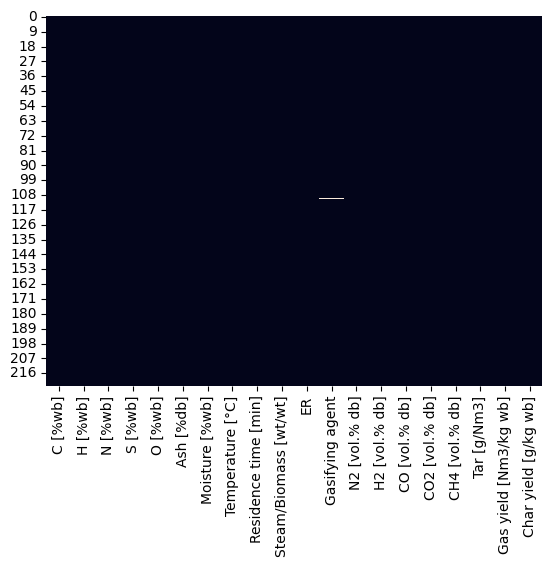

In [19]:
sns.heatmap(df6.isnull(), cbar=False)
plt.show()

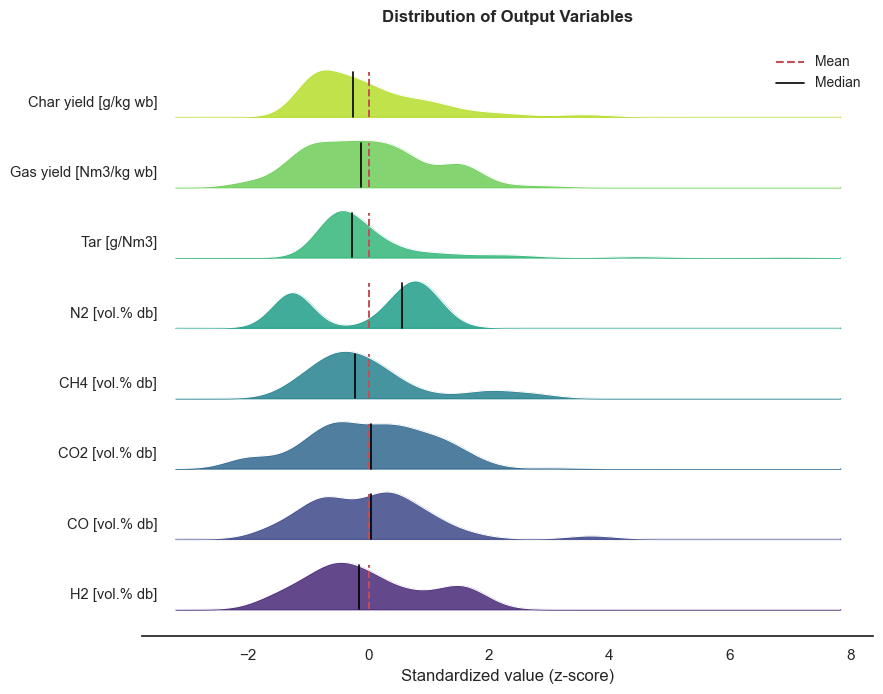

In [ ]:
from scipy.stats import gaussian_kde
sns.set_theme(style="white", font_scale=1.0)

output_cols = [
    'H2 [vol.% db]', 'CO [vol.% db]', 'CO2 [vol.% db]', 'CH4 [vol.% db]',
    'N2 [vol.% db]', 'Tar [g/Nm3]',
    'Gas yield [Nm3/kg wb]', 'Char yield [g/kg wb]'
]

mu, sigma = df_final[output_cols].mean(), df_final[output_cols].std()
df_norm = (df_final[output_cols] - mu) / sigma
n_vars = len(output_cols)

palette = sns.color_palette("viridis", n_vars)
overlap = 1.5
x_grid = np.linspace(df_norm.min().min()-1, df_norm.max().max()+1, 300)

fig, ax = plt.subplots(figsize=(9, 0.7*n_vars + 1.5))

for i, col in enumerate(output_cols):
    data_norm = df_norm[col].dropna().values
    kde = gaussian_kde(data_norm)
    y = kde(x_grid)
    y = y / y.max()
    offset = i * overlap

    ax.fill_between(x_grid, offset, y + offset, color=palette[i], alpha=0.85, zorder=n_vars-i)
    ax.plot(x_grid, y + offset, color='white', linewidth=0.8, zorder=n_vars-i)

    mean_z   = 0.0
    median_z = (df_final[col].median() - mu[col]) / sigma[col]

    ax.plot([mean_z]*2, [offset, offset+0.95], color='#C44E52', linestyle='--', linewidth=1.4, zorder=n_vars+2)
    ax.plot([median_z]*2, [offset, offset+0.95], color='black', linestyle='-', linewidth=1.2, zorder=n_vars+2)
    ax.text(x_grid[0]-0.3, offset+0.15, col, ha='right', va='bottom', fontsize=10.5)

ax.set_yticks([])
ax.set_xlabel("Standardized value (z-score)")
for spine in ['left','right','top']:
    ax.spines[spine].set_visible(False)

legend_elements = [
    Line2D([0], [0], color='#C44E52', linestyle='--', linewidth=1.5, label='Mean'),
    Line2D([0], [0], color='black', linestyle='-', linewidth=1.2, label='Median'),
]
ax.legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=10)
ax.set_title("Distribution of Output Variables", fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("ridgeline_outputs.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
sns.set_theme(style="white")

numeric_cols = df6.select_dtypes(include=[np.number])
matrix = numeric_cols.corr()

n_vars = len(matrix.columns)

fig_width = max(12, n_vars * 0.7)
fig_height = max(10, n_vars * 0.6)
font_size = max(6, 12 - n_vars * 0.3)

# Show only the lower triangle (k=1 hides the diagonal)
mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)

# Diverging palette (red = negative, blue = positive)
cmap = sns.diverging_palette(240, 10, as_cmap=True)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

heatmap = sns.heatmap(
    matrix,
    mask=mask,
    cmap=cmap,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor='white',
    annot=True,
    fmt=".2f",
    annot_kws={'size': 11, 'weight': 'bold'},
    cbar_kws={
        'shrink': 0.6,
        'label': 'Correlation coefficient (r)'
    },
    ax=ax
)

ax.set_title('Correlation Matrix - Gasification\n',
             fontsize=16, fontweight='bold', color='#333333')

plt.xticks(rotation=45, ha='right', fontsize=12, weight='bold')
plt.yticks(rotation=0, fontsize=12, weight='bold')
plt.tight_layout()

fig.savefig('correlation_heatmap_final.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n" + "="*60)
print(f"{'SIGNIFICANT CORRELATION ANALYSIS':^60}")
print("="*60)

corr_pairs = matrix.stack().reset_index()
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

# Remove duplicate pairs (A vs B == B vs A) and the diagonal (r = 1.0)
significant = corr_pairs[
    (abs(corr_pairs['Correlation']) > 0.7) &
    (corr_pairs['Variable 1'] != corr_pairs['Variable 2'])
].sort_values(by='Correlation', ascending=False, key=abs)

if not significant.empty:
    print(f"Found {len(significant)} strong correlations (|r| > 0.7):\n")
    for _, row in significant.iterrows():
        print(f"  - {row['Variable 1']} <-> {row['Variable 2']}:  r = {row['Correlation']:+.3f}")
else:
    print("No strong correlations found (|r| > 0.7).")

In [ ]:
df6.to_csv(r'.\Data\df_gasification_processed.csv', index=False)

In [ ]:

# Optuna-objective function- hyperparameter optimization.
# ============================================================================
tf.keras.backend.clear_session(); gc.collect()

R_GAS  = 8.314e-3; V_MOL = 22.4
MM_C   = 12.011; MM_H = 1.008; MM_O = 15.999
MM_S   = 32.065; MM_H2O = 18.015
EPS    = 1e-7

MM_PHENOL  = 6*MM_C + 6*MM_H + MM_O
MM_BENZENE = 6*MM_C + 6*MM_H
MM_TAR     = (MM_PHENOL + MM_BENZENE) / 2.0
CTAR_FRAC  = (6*MM_C)   / MM_TAR
HTAR_FRAC  = (6*MM_H)   / MM_TAR
OTAR_FRAC  = (0.5*MM_O) / MM_TAR

CCHAR_FRAC = 1.0
HCHAR_FRAC = 0.0
OCHAR_FRAC = 0.0

COL_MOISTURE='Moisture [%wb]'; COL_ASH='Ash [%db]'; COL_AGENT='Gasifying agent'
C_N2_RAW='N2 [vol.% db]'

COLS_X = ['C [%wb]','O [%wb]','H [%wb]','N [%wb]','S [%wb]',
          'Temperature [°C]','ER','Steam/Biomass [wt/wt]',
          'Residence time [min]','air_frac','Moisture [%wb]','Ash [%db]']

COLS_Y_7 = ['CO [vol.% db]','CO2 [vol.% db]','CH4 [vol.% db]','H2 [vol.% db]',
            'Tar [g/Nm3]','Gas yield [Nm3/kg wb]','Char yield [g/kg wb]']

IX_C=0;IX_O=1;IX_H=2;IX_N=3;IX_S=4
IX_T=5;IX_ER=6;IX_SB=7;IX_t=8;IX_AF=9;IX_M=10;IX_A=11

IY7_CO=0;IY7_CO2=1;IY7_CH4=2;IY7_H2=3;IY7_TAR=4;IY7_YGAS=5;IY7_CHAR=6
NAMES_Y7 = ['CO','CO2','CH4','H2','Tar','Ygas','Ychar']

IY6N_CO=0; IY6N_CO2=1; IY6N_H2=2; IY6N_YGAS=3; IY6N_CHAR=4; IY6N_H2O=5

IY_AUG_CO=0; IY_AUG_CO2=1; IY_AUG_H2=2; IY_AUG_YGAS=3; IY_AUG_CHAR=4; IY_AUG_H2O=5
IY_AUG_TAR=6
IY_AUG_CH4=7
IY_AUG_nC=8; IY_AUG_nH=9; IY_AUG_nO=10
IY_AUG_Yc0=11; IY_AUG_t=12; IY_AUG_FCOMB=13; IY_AUG_H2OMAX=14

GAP_R2_MAX = 0.08
BAL_C_MAX  = 0.10
BAL_HO_MAX = 0.15

_BASE_DIR  = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
OUTPUT_DIR = os.path.join(_BASE_DIR, 'HyperparameterResults_cap8', 'v11_tar_relu')
os.makedirs(OUTPUT_DIR, exist_ok=True)
EXCEL_PATH           = os.path.join(OUTPUT_DIR, 'Log_PINN_tar_relu.xlsx')
CHECKPOINT_PATH      = os.path.join(OUTPUT_DIR, 'checkpoint_tar_relu.json')
BEST_MODEL_PATH      = os.path.join(OUTPUT_DIR, 'Best_Model.weights.h5')
BEST_MODEL_ARCH_PATH = os.path.join(OUTPUT_DIR, 'Best_Model_config.json')
PLOTS_DIR            = os.path.join(OUTPUT_DIR, 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

def compute_o2_frac(df):
    agent   = df[COL_AGENT]
    o2_frac = pd.Series(0.232, index=df.index)
    known   = ~agent.isin(['unknown', 'nan', '', 'none'])
    o2_frac[known & agent.str.contains('oxygen', na=False)] = 1.00
    o2_frac[known & agent.eq('steam')]                      = 0.00
    return o2_frac.astype(np.float32)

def compute_ychar0_from_elemental_C(C_wb):
    return np.clip(C_wb/100.0*1000.0, 10.0, None).astype(np.float32)

class ArrheniusLayer(Layer):
    K_MIN=1e-8; K_MAX=0.1
    def __init__(self, T_mean, T_std, **kw):
        super().__init__(**kw)
        self.T_mean=tf.constant(T_mean, dtype=tf.float32)
        self.T_std =tf.constant(T_std,  dtype=tf.float32)
    def call(self, inputs):
        ln_A, Ea_raw, T_norm = inputs
        T_K = tf.clip_by_value(T_norm*self.T_std+self.T_mean, 500.0, 2000.0)
        Ea  = 100.0 + tf.nn.softplus(Ea_raw)*50.0
        return tf.clip_by_value(tf.exp(ln_A-Ea/(R_GAS*T_K)), self.K_MIN, self.K_MAX)
    def get_config(self):
        c=super().get_config()
        c.update({'T_mean':float(self.T_mean.numpy()),'T_std':float(self.T_std.numpy())})
        return c

def build_model(n_inputs, T_mean, T_std, tar_min, tar_max,
                units_kin, units_pred, dropout, activation, l2_reg):
    reg  = tf.keras.regularizers.l2(l2_reg) if l2_reg>0 else None
    init = 'he_normal'
    x_in  = Input(shape=(n_inputs,), name='X_input')
    x_elem= Lambda(lambda x: x[:,:5], name='elemental')(x_in)

    h = x_elem
    for i,u in enumerate(units_kin):
        h = Dense(u, activation='relu', kernel_initializer=init, name=f'kin_{i}')(h)
        if dropout>0: h = Dropout(dropout, name=f'kin_drop_{i}')(h)

    ln_A = Dense(1, activation='linear',
                 kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
                 bias_initializer='zeros', name='ln_A')(h)
    Ea   = Dense(1, activation='softplus',
                 kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
                 bias_initializer=tf.keras.initializers.Constant(0.5),
                 name='Ea')(h)

    T_norm = Lambda(lambda x: tf.expand_dims(x[:,IX_T],1), name='slice_T')(x_in)
    k = ArrheniusLayer(T_mean=T_mean, T_std=T_std, name='arrhenius')([ln_A,Ea,T_norm])

    p = Concatenate(name='X_aug')([x_in, k])
    for i,u in enumerate(units_pred):
        p = Dense(u, activation=activation, kernel_initializer=init,
                  kernel_regularizer=reg, name=f'pred_{i}')(p)
        if dropout>0: p = Dropout(dropout, name=f'pred_drop_{i}')(p)


    sal_6 = Dense(6, activation='linear', name='scaled_outputs_6')(p)

    tar_range = max(tar_max - tar_min, 1e-3)
    tar_sigmoid = Dense(1, activation='sigmoid',
                        kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.05),
                        bias_initializer='zeros', name='tar_head_sigmoid')(p)
    tar_raw = Lambda(lambda x: tar_min + x * tar_range, name='tar_rescale')(tar_sigmoid)

    return Model(inputs=x_in,
                 outputs=Concatenate(name='total_output')([sal_6, tar_raw, k]),
                 name='PINN_v11_tar_relu')

def create_pinn_loss(scaler_y6n, ch4_mean, ch4_std, tar_mean, tar_std, dw, pw, log_tar=False):
    sc_mean  = tf.constant(scaler_y6n.mean_,  dtype=tf.float32)
    sc_scale = tf.constant(scaler_y6n.scale_, dtype=tf.float32)
    ch4_std_safe = tf.constant(max(ch4_std, 1e-3), dtype=tf.float32)
    tar_std_safe = tf.constant(max(tar_std, 1e-3), dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        sc_p6     = y_pred[:, :6]
        tar_raw_p = y_pred[:, 6]     
        y_p6      = sc_p6 * sc_scale + sc_mean

        CO_p=y_p6[:,IY6N_CO]; CO2_p=y_p6[:,IY6N_CO2]; H2_p=y_p6[:,IY6N_H2]
        Ygs_p=y_p6[:,IY6N_YGAS]; Ych_p=y_p6[:,IY6N_CHAR]; H2O_p=y_p6[:,IY6N_H2O]

        Tar_p = tf.math.expm1(tar_raw_p) if log_tar else tar_raw_p

        CH4_p = 100.0 - H2_p - CO_p - CO2_p
        CH4_true = y_true[:, IY_AUG_CH4]
        Tar_true = y_true[:, IY_AUG_TAR]   

        L_data = (
            dw['w_CO']   *tf.reduce_mean(tf.square(sc_p6[:,IY6N_CO]  - y_true[:,IY_AUG_CO]))   +
            dw['w_CO2']  *tf.reduce_mean(tf.square(sc_p6[:,IY6N_CO2] - y_true[:,IY_AUG_CO2]))  +
            dw['w_H2']   *tf.reduce_mean(tf.square(sc_p6[:,IY6N_H2]  - y_true[:,IY_AUG_H2]))   +
            dw['w_YGAS'] *tf.reduce_mean(tf.square(sc_p6[:,IY6N_YGAS]- y_true[:,IY_AUG_YGAS])) +
            dw['w_YCHAR']*tf.reduce_mean(tf.square(sc_p6[:,IY6N_CHAR]- y_true[:,IY_AUG_CHAR])) +
            dw['w_CH4']  *tf.reduce_mean(tf.square((CH4_p - CH4_true) / ch4_std_safe)) +
            dw['w_TAR']  *tf.reduce_mean(tf.square((Tar_p - Tar_true) / tar_std_safe))
        )

        fcomb = y_true[:, IY_AUG_FCOMB]
        Ygs_c = tf.maximum(Ygs_p*fcomb, EPS); n_tot = Ygs_c/V_MOL

        CO_c=tf.nn.relu(CO_p); CO2_c=tf.nn.relu(CO2_p)
        CH4_c=tf.nn.relu(CH4_p); H2_c=tf.nn.relu(H2_p)
        Ych_c=tf.nn.relu(Ych_p); Tar_c=Tar_p; Ygs_p2=tf.nn.relu(Ygs_p)

        n_CO=n_tot*CO_c/100.0; n_CO2=n_tot*CO2_c/100.0
        n_CH4=n_tot*CH4_c/100.0; n_H2=n_tot*H2_c/100.0

        Ychar_g=Ych_c/1000.0; Ytar_g=Tar_c*Ygs_p2/1000.0

        n_C_char=Ychar_g*CCHAR_FRAC/MM_C
        n_H_char=Ychar_g*HCHAR_FRAC/MM_H
        n_O_char=Ychar_g*OCHAR_FRAC/MM_O
        n_C_tar =Ytar_g*CTAR_FRAC/MM_C; n_H_tar=Ytar_g*HTAR_FRAC/MM_H; n_O_tar=Ytar_g*OTAR_FRAC/MM_O

        nC=y_true[:,IY_AUG_nC]; nH=y_true[:,IY_AUG_nH]; nO=y_true[:,IY_AUG_nO]
        Yc0=y_true[:,IY_AUG_Yc0]; t=y_true[:,IY_AUG_t]
        H2O_max_gkg = y_true[:,IY_AUG_H2OMAX] * MM_H2O * 1000.0

        n_C_gas = n_CO+n_CO2+n_CH4
        L_C = tf.reduce_mean(tf.square((n_C_gas+n_C_char+n_C_tar-nC)/(nC+EPS)))

        n_H2O_pred = tf.nn.relu(H2O_p)/1000.0/MM_H2O

        n_O_gas = n_CO+2.0*n_CO2
        L_O = tf.reduce_mean(tf.square(
            (n_O_gas+n_O_tar+n_O_char+n_H2O_pred-nO)/(nO+EPS)))

        n_H_gas = 2.0*n_H2+4.0*n_CH4
        L_H = tf.reduce_mean(tf.square(
            (n_H_gas+n_H_tar+n_H_char+2.0*n_H2O_pred-nH)/(nH+EPS)))

        Ych_p_safe = tf.maximum(Ych_p, EPS)
        L_kin = tf.reduce_mean(tf.square(tf.math.log(Ych_p_safe/Yc0) + k_arr*t))


        L_pos = dw['w_pos']*(
            tf.reduce_mean(tf.square(tf.nn.relu(-Ygs_p)))+
            tf.reduce_mean(tf.square(tf.nn.relu(-Ych_p)))+
            tf.reduce_mean(tf.square(tf.nn.relu(-CO_p))) +
            tf.reduce_mean(tf.square(tf.nn.relu(-CO2_p)))+
            tf.reduce_mean(tf.square(tf.nn.relu(-H2_p))) +
            tf.reduce_mean(tf.square(tf.nn.relu(-CH4_p))) +
            tf.reduce_mean(tf.square(tf.nn.relu(-H2O_p))) +
            tf.reduce_mean(tf.square(tf.nn.relu(H2O_p - H2O_max_gkg)))
        )

        return L_data + pw['w_C']*L_C + pw['w_H']*L_H + pw['w_O']*L_O + pw['w_kin']*L_kin + L_pos

    loss_fn.__name__ = 'pinn_loss_v11_tar_relu'
    return loss_fn

def r2_per_output(yr, yp):
    return {v: float(1-np.sum((yr[:,i]-yp[:,i])**2)/(np.sum((yr[:,i]-yr[:,i].mean())**2)+EPS))
            for i,v in enumerate(NAMES_Y7)}

def mae_per_output(yr, yp):
    return {v: float(np.abs(yr[:,i]-yp[:,i]).mean()) for i,v in enumerate(NAMES_Y7)}

def compute_gap_r2(r2_tr, r2_va):
    gap     = {n: abs(r2_tr[n]-r2_va[n]) for n in NAMES_Y7}
    gap_ok  = all(v<=GAP_R2_MAX for v in gap.values())
    gap_max = max(gap.values())
    return gap, gap_ok, gap_max

def assemble_outputs(raw_pred_8col, sy6n, log_tar=False):
    sc_p6     = raw_pred_8col[:, :6]
    tar_raw_p = raw_pred_8col[:, 6]
    k_arr     = raw_pred_8col[:, 7]
    y6n = sc_p6*sy6n.scale_ + sy6n.mean_

    CO, CO2, H2, Ygas, Char, H2O = (y6n[:,0], y6n[:,1], y6n[:,2],
                                     y6n[:,3], y6n[:,4], y6n[:,5])
    Tar = np.expm1(tar_raw_p) if log_tar else tar_raw_p
    CH4 = 100.0 - H2 - CO - CO2

    y7 = np.column_stack([CO, CO2, CH4, H2, Tar, Ygas, Char])  
    h2o_pred = np.maximum(H2O, 0.0)
    return y7, h2o_pred, k_arr

def compute_n_O2_stoich_wb(X):
    C_wb=X[:,IX_C]/100.0; H_wb=X[:,IX_H]/100.0
    O_wb=X[:,IX_O]/100.0; S_wb=X[:,IX_S]/100.0
    n_O2 = C_wb/MM_C + H_wb/(4.0*MM_H) + S_wb/MM_S - O_wb/(2.0*MM_O)
    return n_O2.astype(np.float32)

def compute_input_moles(X):
    n_O2=compute_n_O2_stoich_wb(X)
    nC=(X[:,IX_C]/100/MM_C).astype(np.float32)
    nH=(X[:,IX_H]/100/MM_H+2.0*X[:,IX_M]/100/MM_H2O+2.0*X[:,IX_SB]/MM_H2O).astype(np.float32)
    nO=(X[:,IX_O]/100/MM_O+X[:,IX_M]/100/MM_H2O+X[:,IX_ER]*n_O2*2.0+X[:,IX_SB]/MM_H2O).astype(np.float32)
    return nC, nH, nO

def compute_H2O_init_estimate(X, y7_raw_full, frac_comb):
    nC, nH, nO = compute_input_moles(X)
    CO   = y7_raw_full[:,IY7_CO];   CO2  = y7_raw_full[:,IY7_CO2]
    CH4  = y7_raw_full[:,IY7_CH4];  H2   = y7_raw_full[:,IY7_H2]
    Tar  = y7_raw_full[:,IY7_TAR];  Ygas = y7_raw_full[:,IY7_YGAS]
    Char = y7_raw_full[:,IY7_CHAR]

    Ygas_c = np.maximum(Ygas*frac_comb, EPS)
    n_tot  = Ygas_c / V_MOL
    n_CO=n_tot*CO/100.0; n_CO2=n_tot*CO2/100.0
    n_CH4=n_tot*CH4/100.0; n_H2=n_tot*H2/100.0

    Ychar_g  = Char/1000.0
    n_C_char = Ychar_g*CCHAR_FRAC/MM_C

    Ytar_g  = Tar*Ygas/1000.0
    n_C_tar = Ytar_g*CTAR_FRAC/MM_C
    n_H_tar = Ytar_g*HTAR_FRAC/MM_H
    n_O_tar = Ytar_g*OTAR_FRAC/MM_O

    n_O_gas = n_CO + 2.0*n_CO2
    n_H_gas = 2.0*n_H2 + 4.0*n_CH4

    H2O_by_O = nO - n_O_gas - n_O_tar
    H2O_by_H = (nH - n_H_gas - n_H_tar) / 2.0

    H2O_max_mol = nH / 2.0
    H2O_mol = np.clip((H2O_by_O + H2O_by_H) / 2.0, 0.0, H2O_max_mol)
    return (H2O_mol * MM_H2O * 1000.0).astype(np.float32)

def verify_balances_np(yp7, h2o_pred_g_kg, nC, nH, nO, frac_comb, log_tar=False):
    Ygas_p=yp7[:,IY7_YGAS]; Ygas_c=np.maximum(Ygas_p*frac_comb,EPS); n_tot=Ygas_c/V_MOL
    CO_c=np.maximum(yp7[:,IY7_CO],0.0); CO2_c=np.maximum(yp7[:,IY7_CO2],0.0)
    CH4_c=np.maximum(yp7[:,IY7_CH4],0.0); H2_c=np.maximum(yp7[:,IY7_H2],0.0)
    Ych_c=np.maximum(yp7[:,IY7_CHAR],0.0)
    Tar_c=np.maximum(yp7[:,IY7_TAR],0.0); Ygs_p2=np.maximum(Ygas_p,EPS)

    n_CO=n_tot*CO_c/100; n_CO2=n_tot*CO2_c/100
    n_CH4=n_tot*CH4_c/100; n_H2=n_tot*H2_c/100

    Ychar_g=Ych_c/1000; Ytar_g=Tar_c*Ygs_p2/1000
    n_C_char=Ychar_g*CCHAR_FRAC/MM_C; n_H_char=Ychar_g*HCHAR_FRAC/MM_H; n_O_char=Ychar_g*OCHAR_FRAC/MM_O
    n_C_tar=Ytar_g*CTAR_FRAC/MM_C; n_H_tar=Ytar_g*HTAR_FRAC/MM_H; n_O_tar=Ytar_g*OTAR_FRAC/MM_O

    n_C_gas=n_CO+n_CO2+n_CH4
    n_O_gas=n_CO+2*n_CO2
    n_H2O_pred = (h2o_pred_g_kg/1000.0)/MM_H2O

    res_C=n_C_gas+n_C_char+n_C_tar-nC
    res_H=2*n_H2+4*n_CH4+n_H_tar+n_H_char+2*n_H2O_pred-nH
    res_O=n_O_gas+n_O_tar+n_O_char+n_H2O_pred-nO

    return {
        'err_C_abs':float(np.abs(res_C).mean()),
        'err_H_abs':float(np.abs(res_H).mean()),
        'err_O_abs':float(np.abs(res_O).mean()),
        'err_C_rel':float((np.abs(res_C)/(nC+EPS)).mean()),
        'err_H_rel':float((np.abs(res_H)/(nH+EPS)).mean()),
        'err_O_rel':float((np.abs(res_O)/(nO+EPS)).mean()),
        'H2O_pred_mean':float(h2o_pred_g_kg.mean()),
        'H2O_pred_std':float(h2o_pred_g_kg.std()),
        'H2O_pred_min':float(h2o_pred_g_kg.min()),
        'H2O_pred_max':float(h2o_pred_g_kg.max()),
        'CCE_pred':float((np.maximum(n_C_gas,0.0)/(nC+EPS)*100).mean()),
    }

def count_negatives(yp7, h2o_pred_g_kg, log_tar=False):
    out = {}
    for i, n in enumerate(NAMES_Y7):
        vals = yp7[:, i]
        out[f'negfrac_{n}'] = float((vals < 0).mean())
    out['negfrac_H2O'] = float((h2o_pred_g_kg < 0).mean())
    sum_gas = yp7[:,IY7_CO]+yp7[:,IY7_CO2]+yp7[:,IY7_CH4]+yp7[:,IY7_H2]
    out['frac_sum_gas_over100'] = float((sum_gas > 100.0).mean())
    return out

def compute_global_balance(fb, fn):
    N=sum(fn); w=[n/N for n in fn]
    keys=['err_C_abs','err_H_abs','err_O_abs','err_C_rel','err_H_rel','err_O_rel',
          'H2O_pred_mean','CCE_pred']
    r={f'Bal_{k}_global':float(np.average([d[k] for d in fb],weights=w)) for k in keys}
    r['Bal_Score']=float(np.exp(-(r['Bal_err_C_rel_global']+r['Bal_err_H_rel_global']+r['Bal_err_O_rel_global'])/3.0))
    return r

COLS_ELEMENTAL_WB = ['C [%wb]', 'H [%wb]', 'N [%wb]', 'S [%wb]', 'O [%wb]']

def prepare_dataframe_for_pinn(df_final, verbose=True):
    df = df_final.copy()
    n_before = len(df)

    if COL_AGENT in df.columns:
        mask_missing_original = df[COL_AGENT].isna()
        normalized_agent = df[COL_AGENT].astype(str).str.lower().str.strip()
        mask_str_nan = normalized_agent.isin(['nan', 'none', ''])
        mask_nan_agent = (mask_missing_original | mask_str_nan).fillna(True)
        if mask_nan_agent.any():
            print(f"  Warning: {int(mask_nan_agent.sum())} row(s) with 'Gasifying agent' "
                  f"NaN/empty -- dropped.")
        df = df.loc[~mask_nan_agent].reset_index(drop=True)
        df[COL_AGENT] = df[COL_AGENT].astype(str).str.lower().str.strip()

    missing_wb = [c for c in COLS_ELEMENTAL_WB if c not in df.columns]
    if missing_wb:
        raise ValueError(
            f"Expected %wb columns ({COLS_ELEMENTAL_WB}), missing: {missing_wb}."
        )

    df['air_frac'] = compute_o2_frac(df)

    missing_cols = [c for c in COLS_X + COLS_Y_7 if c not in df.columns]
    if missing_cols:
        raise ValueError(f'Missing columns: {missing_cols}')
    if C_N2_RAW not in df.columns:
        raise ValueError(f"Missing '{C_N2_RAW}'.")

    cols_dup = (['Temperature [°C]','ER','Steam/Biomass [wt/wt]',
                 'Residence time [min]'] + COLS_Y_7)
    dup_mask = df[cols_dup].round(3).duplicated(keep='first')
    df = df[~dup_mask].reset_index(drop=True)
    n_dup = int(dup_mask.sum())

    mc = df[COL_AGENT].isin(['air','oxygen']) & (df['ER'].fillna(0) == 0)
    n_mc = int(mc.sum())
    df = df[~mc].reset_index(drop=True)

    gas4 = ['CO [vol.% db]','CO2 [vol.% db]','CH4 [vol.% db]','H2 [vol.% db]']
    sum4 = df[gas4].sum(axis=1).clip(lower=EPS)
    n2_real = df[C_N2_RAW].fillna(0.0)
    df['_frac_comb'] = (1.0 - n2_real/100.0).clip(EPS, 1.0).astype(np.float32)
    for cg in gas4:
        df[cg] = df[cg] / sum4 * 100.0

    df['Temperature [°C]']     = df['Temperature [°C]'] + 273.15
    df['Residence time [min]'] = df['Residence time [min]'] * 60.0
    df = df.rename(columns={'Temperature [°C]':'T_K', 'Residence time [min]':'t_s'})

    col_x = ['C [%wb]','O [%wb]','H [%wb]','N [%wb]','S [%wb]','T_K','ER',
             'Steam/Biomass [wt/wt]','t_s','air_frac','Moisture [%wb]','Ash [%db]']
    col_y7 = ['CO [vol.% db]','CO2 [vol.% db]','CH4 [vol.% db]','H2 [vol.% db]',
              'Tar [g/Nm3]','Gas yield [Nm3/kg wb]','Char yield [g/kg wb]']

    X_raw  = df[col_x].values.astype(np.float32)
    y7_raw = df[col_y7].values.astype(np.float32)
    ychar0_raw   = compute_ychar0_from_elemental_C(X_raw[:, IX_C])
    agents_raw   = df[COL_AGENT].values
    frac_comb_raw= df['_frac_comb'].values.astype(np.float32)

    if verbose:
        cnt = Counter(agents_raw)
        nC,nH,nO = compute_input_moles(X_raw)
        print(f"\n{'='*65}")
        print(f"  PREPARE_DATAFRAME_FOR_PINN v11 - {len(df)} rows (of {n_before})")
        print(f"    -{n_dup} exact duplicates, -{n_mc} oxidant+ER=0")
        print(f"  nC={nC.mean():.5f}  nH={nH.mean():.5f}  nO={nO.mean():.5f}  mol/g_wb")
        print(f"  frac_comb: mean={frac_comb_raw.mean():.3f} "
              f"[{frac_comb_raw.min():.3f},{frac_comb_raw.max():.3f}]")
        for ag, n in sorted(cnt.items(), key=lambda x: -x[1]):
            print(f"    {ag:20s}: {n:4d} ({n/len(df)*100:5.1f}%)")
        print(f"{'='*65}\n")

    return X_raw, y7_raw, col_x, ychar0_raw, agents_raw, frac_comb_raw

def create_splits(X_raw, n_splits=5, random_state=42):
    kf=KFold(n_splits=n_splits,shuffle=True,random_state=random_state)
    splits=list(kf.split(X_raw))
    print(f'  KFold: {n_splits} folds')
    for fi,(_,va_idx) in enumerate(splits):
        print(f'    Fold {fi+1}: val n={len(va_idx)}')
    print(); return splits

def preprocess_fold(X_raw, y7_raw, ychar0_raw, frac_comb, train_idx, val_idx, log_tar=False):
    X_tr=X_raw[train_idx]; X_va=X_raw[val_idx]
    y_tr=y7_raw[train_idx].copy(); y_va=y7_raw[val_idx].copy()
    fc_tr=frac_comb[train_idx]; fc_va=frac_comb[val_idx]

    if log_tar:
        y_tr[:,IY7_TAR]=np.log1p(y_tr[:,IY7_TAR]); y_va[:,IY7_TAR]=np.log1p(y_va[:,IY7_TAR])
    tar_p95=float(np.percentile(y_tr[:,IY7_TAR],95))
    y_tr[:,IY7_TAR]=np.clip(y_tr[:,IY7_TAR],0.0,tar_p95)
    y_va[:,IY7_TAR]=np.clip(y_va[:,IY7_TAR],0.0,tar_p95)

    H2O_init_tr = compute_H2O_init_estimate(X_tr, y_tr, fc_tr)
    H2O_init_va = compute_H2O_init_estimate(X_va, y_va, fc_va)


    ch4_tr = y_tr[:, IY7_CH4].copy(); ch4_va = y_va[:, IY7_CH4].copy()
    tar_tr = y_tr[:, IY7_TAR].copy(); tar_va = y_va[:, IY7_TAR].copy()   
    y_tr_5cols = np.delete(y_tr, [IY7_CH4, IY7_TAR], axis=1)  
    y_va_5cols = np.delete(y_va, [IY7_CH4, IY7_TAR], axis=1)

    y_tr_6net = np.column_stack([y_tr_5cols, H2O_init_tr])  
    y_va_6net = np.column_stack([y_va_5cols, H2O_init_va])

    sX   = StandardScaler().fit(X_tr)
    sy6n = StandardScaler().fit(y_tr_6net)
    X_tr_sc = sX.transform(X_tr).astype(np.float32); X_va_sc = sX.transform(X_va).astype(np.float32)
    y_tr_sc = sy6n.transform(y_tr_6net).astype(np.float32); y_va_sc = sy6n.transform(y_va_6net).astype(np.float32)

    ch4_mean = float(ch4_tr.mean()); ch4_std = float(ch4_tr.std())
    tar_mean = float(tar_tr.mean()); tar_std = float(tar_tr.std())
    tar_min  = float(tar_tr.min());  tar_max  = float(tar_tr.max())

    Tm=float(sX.mean_[IX_T]); Ts=float(np.sqrt(sX.var_[IX_T]))
    nC_tr,nH_tr,nO_tr=compute_input_moles(X_tr); nC_va,nH_va,nO_va=compute_input_moles(X_va)
    Yc0_tr=ychar0_raw[train_idx]; Yc0_va=ychar0_raw[val_idx]
    t_tr=X_raw[train_idx,IX_t].astype(np.float32); t_va=X_raw[val_idx,IX_t].astype(np.float32)

    h2o_max_tr = nH_tr / 2.0
    h2o_max_va = nH_va / 2.0

    y_tr_aug=np.column_stack([y_tr_sc, tar_tr, ch4_tr, nC_tr,nH_tr,nO_tr,Yc0_tr,t_tr,fc_tr,h2o_max_tr]).astype(np.float32)
    y_va_aug=np.column_stack([y_va_sc, tar_va, ch4_va, nC_va,nH_va,nO_va,Yc0_va,t_va,fc_va,h2o_max_va]).astype(np.float32)

    return (X_tr_sc, X_va_sc, y_tr_aug, y_va_aug, y_tr_sc, y_va_sc,
            sX, sy6n, Tm, Ts, ch4_mean, ch4_std, tar_mean, tar_std,
            tar_min, tar_max, log_tar)

PUB_RC={'font.family':'sans-serif','font.size':13,'axes.titlesize':13,
        'axes.labelsize':11,'figure.dpi':300,'savefig.dpi':300,
        'savefig.facecolor':'white','savefig.bbox':'tight',
        'axes.spines.top':False,'axes.spines.right':False,'axes.grid':False}
C_TRAIN='#E65100'; C_TEST='#1A237E'; C_IDEAL='#388E3C'
C_WONG=['#E69F00','#56B4E9','#009E73','#D55E00']
VAR_UNITS=['vol.% db','vol.% db','vol.% db','vol.% db','g Nm-3','Nm3 kg-1','g kg-1']

def _save(fig, path):
    fig.savefig(path,dpi=300,bbox_inches='tight',facecolor='white'); plt.close(fig)

def plot_pred_vs_real(yp7_tr, yt7_tr, yp7_va, yt7_va, combo_key):
    with plt.rc_context(PUB_RC):
        fig,axes=plt.subplots(2,4,figsize=(5.5*4,5.5*2)); axes=axes.flatten()
        for i,(n,u) in enumerate(zip(NAMES_Y7,VAR_UNITS)):
            ax=axes[i]
            all_v=np.concatenate([yt7_tr[:,i],yp7_tr[:,i],yt7_va[:,i],yp7_va[:,i]])
            lo=all_v.min()-abs(all_v.min())*0.07; hi=all_v.max()*1.07
            ax.plot([lo,hi],[lo,hi],color=C_IDEAL,lw=1.5,ls='--',zorder=1)
            ax.scatter(yt7_tr[:,i],yp7_tr[:,i],marker='o',s=25,facecolors='none',
                       edgecolors=C_TRAIN,linewidths=1.0,alpha=0.55,zorder=2,label='Train')
            ax.scatter(yt7_va[:,i],yp7_va[:,i],marker='^',s=30,facecolors=C_TEST,
                       edgecolors=C_TEST,linewidths=0.4,alpha=0.85,zorder=3,label='Val')
            r2=1-np.sum((yt7_va[:,i]-yp7_va[:,i])**2)/(np.sum((yt7_va[:,i]-yt7_va[:,i].mean())**2)+EPS)
            mae=np.abs(yt7_va[:,i]-yp7_va[:,i]).mean()
            ax.text(0.05,0.95,f'R2={r2:.3f}\nMAE={mae:.2f}',
                    transform=ax.transAxes,fontsize=10,va='top',
                    bbox=dict(boxstyle='round,pad=0.3',fc='white',ec='0.4',alpha=0.95))
            ax.set_xlim(lo,hi); ax.set_ylim(lo,hi)
            ax.set_xlabel(f'Measured [{u}]'); ax.set_ylabel(f'Predicted [{u}]')
            ax.set_title(n,fontweight='bold'); ax.legend(fontsize=8,loc='lower right')
        axes[-1].set_visible(False)
        fig.suptitle(f'Pred vs Real - {combo_key[:60]}',fontsize=12,fontweight='bold',y=1.01)
        plt.tight_layout()
        fname=combo_key.replace('[','').replace(']','').replace(', ','_').replace(' ','').replace(',','_')
        _save(fig,os.path.join(PLOTS_DIR,f'pred_{fname[:80]}.png'))

N_FOLDS    = 3
LOG_TAR    = False
BATCH_SIZE = 16
EPOCHS_MAX = 800
PATIENCE   = 50

class PruningCallback(tf.keras.callbacks.Callback):
    def __init__(self, trial, monitor='val_loss'):
        super().__init__()
        self.trial = trial
        self.monitor = monitor

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return
        self.trial.report(float(current), step=epoch)
        if self.trial.should_prune():
            self.model.stop_training = True
            raise optuna.TrialPruned(
                f"Trial pruned at epoch {epoch} ({self.monitor}={current:.4f})")


def _preprocess_folds_once(df_final, n_folds=3):
    X_raw, y7_raw, col_x, ychar0_raw, agents_raw, frac_comb_raw = \
        prepare_dataframe_for_pinn(df_final, verbose=True)
    fold_splits = create_splits(X_raw, n_folds)

    folds_data = []
    for tr_idx, va_idx in fold_splits:
        folds_data.append(preprocess_fold(
            X_raw, y7_raw, ychar0_raw, frac_comb_raw, tr_idx, va_idx,
            log_tar=LOG_TAR))
    return folds_data

DW_FIXED = {'name':'no_pos', 'w_CO':2.0,'w_CO2':2.5,'w_CH4':3.0,'w_H2':2.5,
            'w_TAR':10.0,'w_YGAS':2.0,'w_YCHAR':8.0,'w_pos':0.0}


def _build_yt7(real6, y_aug, log_tar):
    """Reconstructs the 7-output ground-truth vector, with raw Tar
    (un-logged if applicable) taken from its own column in y_aug."""
    tar_true = y_aug[:, IY_AUG_TAR]
    if log_tar:
        tar_true = np.expm1(tar_true)
    return np.column_stack([
        real6[:, IY6N_CO], real6[:, IY6N_CO2], y_aug[:, IY_AUG_CH4],
        real6[:, IY6N_H2], tar_true, real6[:, IY6N_YGAS], real6[:, IY6N_CHAR]])


def _build_optimizer(opt_name, lr):
    if opt_name == 'adam':
        return tf.keras.optimizers.Adam(lr)
    elif opt_name == 'nadam':
        return tf.keras.optimizers.Nadam(lr)
    elif opt_name == 'rmsprop':
        return tf.keras.optimizers.RMSprop(lr)
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")


def _train_one_fold(trial, fold_data, up, uk, act, lr, drop, l2, opt_name, batch_size, pw):
    (X_tr, X_va, y_tr_aug, y_va_aug, y_tr_sc, y_va_sc,
     sX, sy6n, Tm, Ts, ch4_mean, ch4_std, tar_mean, tar_std,
     tar_min, tar_max, lt) = fold_data

    model   = build_model(X_tr.shape[1], Tm, Ts, tar_min, tar_max, uk, up, drop, act, l2)
    loss_fn = create_pinn_loss(sy6n, ch4_mean, ch4_std, tar_mean, tar_std,
                                DW_FIXED, pw, log_tar=lt)
    optimizer = _build_optimizer(opt_name, lr)
    model.compile(optimizer=optimizer, loss=loss_fn)

    prune_cb = PruningCallback(trial, 'val_loss')

    model.fit(
        X_tr, y_tr_aug, batch_size=batch_size, epochs=EPOCHS_MAX,
        validation_data=(X_va, y_va_aug), verbose=0,
        callbacks=[
            tf.keras.callbacks.EarlyStopping('val_loss', patience=PATIENCE,
                                             min_delta=1e-6, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau('val_loss', factor=0.4,
                                                  patience=int(PATIENCE*0.4), min_lr=1e-7),
            prune_cb,
        ])

    ptr = model.predict(X_tr, verbose=0)
    pva = model.predict(X_va, verbose=0)
    yp7_tr, _, _      = assemble_outputs(ptr, sy6n, log_tar=lt)
    yp7_va, h2o_va, _ = assemble_outputs(pva, sy6n, log_tar=lt)

    real6_tr = y_tr_aug[:, :6] * sy6n.scale_ + sy6n.mean_
    real6_va = y_va_aug[:, :6] * sy6n.scale_ + sy6n.mean_

    yt7_tr = _build_yt7(real6_tr, y_tr_aug, lt)
    yt7_va = _build_yt7(real6_va, y_va_aug, lt)

    r2_tr = r2_per_output(yt7_tr, yp7_tr)
    r2_va = r2_per_output(yt7_va, yp7_va)
    tr_r2 = float(np.mean(list(r2_tr.values())))
    va_r2 = float(np.mean(list(r2_va.values())))
    gap = abs(tr_r2 - va_r2)

    nC_ = y_va_aug[:, IY_AUG_nC]; nH_ = y_va_aug[:, IY_AUG_nH]; nO_ = y_va_aug[:, IY_AUG_nO]
    bal = verify_balances_np(yp7_va, h2o_va, nC_, nH_, nO_,
                             y_va_aug[:, IY_AUG_FCOMB], log_tar=lt)
    negs = count_negatives(yp7_va, h2o_va, log_tar=lt)
    bal_ok = bal['err_C_rel'] < BAL_C_MAX

    del model
    tf.keras.backend.clear_session(); gc.collect()

    return va_r2, gap, bal, bal_ok, negs


def make_objective(folds_data):
    def objective(trial):
        up_opt = trial.suggest_categorical(
            'units_pred', ['128_64', '256_128', '256_128_64',
                           '512_256_128', '512_256_128_64'])
        up_map = {'128_64': [128, 64], '256_128': [256, 128],
                  '256_128_64': [256, 128, 64],
                  '512_256_128': [512, 256, 128],
                  '512_256_128_64': [512, 256, 128, 64]}
        up = up_map[up_opt]

        uk_opt = trial.suggest_categorical('units_kin', ['32_32', '64_64', '128_64'])
        uk_map = {'32_32': [32, 32], '64_64': [64, 64], '128_64': [128, 64]}
        uk = uk_map[uk_opt]

        act  = trial.suggest_categorical('activation', ['relu', 'swish', 'gelu', 'elu'])
        opt_name = trial.suggest_categorical('optimizer', ['adam', 'nadam', 'rmsprop'])
        lr   = trial.suggest_float('lr', 3e-4, 5e-3, log=True)
        drop = trial.suggest_float('dropout', 0.02, 0.30)
        l2   = trial.suggest_float('l2', 1e-6, 2e-3, log=True)
        batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64, 128])

        w_C   = trial.suggest_float('w_C', 1.0, 10.0)
        w_H   = trial.suggest_float('w_H', 2.0, 35.0)
        w_O   = trial.suggest_float('w_O', 2.0, 35.0)
        w_kin = trial.suggest_float('w_kin', 0.5, 6.0)
        pw = {'name':'optuna', 'w_C':w_C, 'w_H':w_H, 'w_O':w_O, 'w_kin':w_kin}

        r2s, gaps, bals, bal_oks, negs_list = [], [], [], [], []
        for fold_data in folds_data:
            va_r2, gap, bal, bal_ok, negs = _train_one_fold(
                trial, fold_data, up, uk, act, lr, drop, l2, opt_name, batch_size, pw)
            r2s.append(va_r2); gaps.append(gap); bals.append(bal)
            bal_oks.append(bal_ok); negs_list.append(negs)

        vr = float(np.mean(r2s))
        mean_gap = float(np.mean(gaps))
        bal_c_rel = float(np.mean([b['err_C_rel'] for b in bals]))
        bal_h_rel = float(np.mean([b['err_H_rel'] for b in bals]))
        bal_o_rel = float(np.mean([b['err_O_rel'] for b in bals]))
        tar_negfrac = float(np.mean([n['negfrac_Tar'] for n in negs_list]))


        gap_score = float(np.exp(-mean_gap / 0.15))
        bal_c_score = max(0.0, 1.0 - bal_c_rel / BAL_C_MAX)
        bal_h_score = max(0.0, 1.0 - bal_h_rel / BAL_C_MAX)
        bal_o_score = max(0.0, 1.0 - bal_o_rel / BAL_C_MAX)
        bal_score = (bal_c_score + bal_h_score + bal_o_score) / 3.0

        score = (vr + bal_score + gap_score) / 3.0

        trial.set_user_attr('va_r2', vr)
        trial.set_user_attr('mean_gap', mean_gap)
        trial.set_user_attr('bal_c_rel', bal_c_rel)
        trial.set_user_attr('bal_h_rel', bal_h_rel)
        trial.set_user_attr('bal_o_rel', bal_o_rel)
        trial.set_user_attr('tar_negfrac', tar_negfrac)

        return score
    return objective


class SaveProgressCallback:
    def __init__(self, pkl_path, csv_path):
        self.pkl_path = pkl_path
        self.csv_path = csv_path

    def __call__(self, study, trial):
        joblib.dump(study, self.pkl_path)
        study.trials_dataframe().to_csv(self.csv_path, index=False)


def run_optuna_combined_obj3(df_final, n_trials=200, n_folds=3, seed=42,
                              pkl_path='optuna_all_combined_obj3_final.pkl',
                              csv_path='optuna_all_combined_obj3_final.csv'):
    print(f"Precomputing data for {n_folds} folds...")
    folds_data = _preprocess_folds_once(df_final, n_folds=n_folds)

    if os.path.exists(pkl_path):
        study = joblib.load(pkl_path)
        print(f"Existing study loaded: {len(study.trials)} trials already done. "
              f"Adding {n_trials} more.")
    else:
        sampler = optuna.samplers.TPESampler(seed=seed)
        pruner  = optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=40)
        study = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)
        print("No previous study -- starting from scratch.")

    objective = make_objective(folds_data)
    progress_cb = SaveProgressCallback(pkl_path, csv_path)
    study.optimize(objective, n_trials=n_trials, catch=(Exception,), callbacks=[progress_cb])

    print("\n" + "="*70)
    print(f"  OPTUNA ALL COMBINED (architecture + batch_size + optimizer + "
          f"physical weights) - BEST TRIAL (of {len(study.trials)} trials)")
    print("="*70)
    bt = study.best_trial
    print(f"  Score       : {bt.value:.4f}")
    print(f"  R2 (val)    : {bt.user_attrs.get('va_r2', float('nan')):.4f}")
    print(f"  Gap         : {bt.user_attrs.get('mean_gap', float('nan')):.4f}")
    print(f"  BalC (rel)  : {bt.user_attrs.get('bal_c_rel', float('nan'))*100:.1f}%")
    print(f"  BalH (rel)  : {bt.user_attrs.get('bal_h_rel', float('nan'))*100:.1f}%")
    print(f"  BalO (rel)  : {bt.user_attrs.get('bal_o_rel', float('nan'))*100:.1f}%")
    print(f"  Tar_negfrac : {bt.user_attrs.get('tar_negfrac', float('nan'))*100:.2f}%")
    print(f"  Hyperparams : {bt.params}")
    print("="*70)

    n_pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
    n_completed = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
    print(f"  Completed trials: {n_completed}   Pruned: {n_pruned}")

    print("\n  TOP 10 TRIALS:")
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    top10 = sorted(completed, key=lambda t: -t.value)[:10]
    for i, t in enumerate(top10, 1):
        print(f"  #{i} Score={t.value:.4f} R2={t.user_attrs.get('va_r2',0):.4f} "
              f"Gap={t.user_attrs.get('mean_gap',0):.4f} "
              f"BalC={t.user_attrs.get('bal_c_rel',0)*100:.1f}% "
              f"BalH={t.user_attrs.get('bal_h_rel',0)*100:.1f}% "
              f"BalO={t.user_attrs.get('bal_o_rel',0)*100:.1f}% "
              f"TarNeg={t.user_attrs.get('tar_negfrac',0)*100:.2f}%")
        print(f"      Params={t.params}")

    return study


study_all_combined_obj3 = run_optuna_combined_obj3(df_final_ok, n_trials=200, n_folds=3)

In [ ]:

# Optuna-Multi-objective (Pareto)- hyperparameter optimization.
# ============================================================================
tf.keras.backend.clear_session(); gc.collect()

R_GAS  = 8.314e-3; V_MOL = 22.4
MM_C   = 12.011; MM_H = 1.008; MM_O = 15.999
MM_S   = 32.065; MM_H2O = 18.015
EPS    = 1e-7

MM_PHENOL  = 6*MM_C + 6*MM_H + MM_O
MM_BENZENE = 6*MM_C + 6*MM_H
MM_TAR     = (MM_PHENOL + MM_BENZENE) / 2.0
CTAR_FRAC  = (6*MM_C)   / MM_TAR
HTAR_FRAC  = (6*MM_H)   / MM_TAR
OTAR_FRAC  = (0.5*MM_O) / MM_TAR

CCHAR_FRAC = 1.0
HCHAR_FRAC = 0.0
OCHAR_FRAC = 0.0

COL_MOISTURE='Moisture [%wb]'; COL_ASH='Ash [%db]'; COL_AGENT='Gasifying agent'
C_N2_RAW='N2 [vol.% db]'

COLS_X = ['C [%wb]','O [%wb]','H [%wb]','N [%wb]','S [%wb]',
          'Temperature [°C]','ER','Steam/Biomass [wt/wt]',
          'Residence time [min]','air_frac','Moisture [%wb]','Ash [%db]']

COLS_Y_7 = ['CO [vol.% db]','CO2 [vol.% db]','CH4 [vol.% db]','H2 [vol.% db]',
            'Tar [g/Nm3]','Gas yield [Nm3/kg wb]','Char yield [g/kg wb]']

IX_C=0;IX_O=1;IX_H=2;IX_N=3;IX_S=4
IX_T=5;IX_ER=6;IX_SB=7;IX_t=8;IX_AF=9;IX_M=10;IX_A=11

IY7_CO=0;IY7_CO2=1;IY7_CH4=2;IY7_H2=3;IY7_TAR=4;IY7_YGAS=5;IY7_CHAR=6
NAMES_Y7 = ['CO','CO2','CH4','H2','Tar','Ygas','Ychar']

IY6N_CO=0; IY6N_CO2=1; IY6N_H2=2; IY6N_YGAS=3; IY6N_CHAR=4; IY6N_H2O=5


IY_AUG_CO=0; IY_AUG_CO2=1; IY_AUG_H2=2; IY_AUG_YGAS=3; IY_AUG_CHAR=4; IY_AUG_H2O=5
IY_AUG_TAR=6
IY_AUG_CH4=7
IY_AUG_nC=8; IY_AUG_nH=9; IY_AUG_nO=10
IY_AUG_Yc0=11; IY_AUG_t=12; IY_AUG_FCOMB=13; IY_AUG_H2OMAX=14

GAP_R2_MAX = 0.08
BAL_C_MAX  = 0.10
BAL_HO_MAX = 0.15

_BASE_DIR  = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
OUTPUT_DIR = os.path.join(_BASE_DIR, 'HyperparameterResults_cap8', 'v11_tar_relu')
os.makedirs(OUTPUT_DIR, exist_ok=True)
EXCEL_PATH           = os.path.join(OUTPUT_DIR, 'Log_PINN_tar_relu.xlsx')
CHECKPOINT_PATH      = os.path.join(OUTPUT_DIR, 'checkpoint_tar_relu.json')
BEST_MODEL_PATH      = os.path.join(OUTPUT_DIR, 'Best_Model.weights.h5')
BEST_MODEL_ARCH_PATH = os.path.join(OUTPUT_DIR, 'Best_Model_config.json')
PLOTS_DIR            = os.path.join(OUTPUT_DIR, 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

def compute_o2_frac(df):
    agent   = df[COL_AGENT]
    o2_frac = pd.Series(0.232, index=df.index)
    known   = ~agent.isin(['unknown', 'nan', '', 'none'])
    o2_frac[known & agent.str.contains('oxygen', na=False)] = 1.00
    o2_frac[known & agent.eq('steam')]                      = 0.00
    return o2_frac.astype(np.float32)

def compute_ychar0_from_elemental_C(C_wb):
    return np.clip(C_wb/100.0*1000.0, 10.0, None).astype(np.float32)

class ArrheniusLayer(Layer):
    K_MIN=1e-8; K_MAX=0.1
    def __init__(self, T_mean, T_std, **kw):
        super().__init__(**kw)
        self.T_mean=tf.constant(T_mean, dtype=tf.float32)
        self.T_std =tf.constant(T_std,  dtype=tf.float32)
    def call(self, inputs):
        ln_A, Ea_raw, T_norm = inputs
        T_K = tf.clip_by_value(T_norm*self.T_std+self.T_mean, 500.0, 2000.0)
        Ea  = 100.0 + tf.nn.softplus(Ea_raw)*50.0
        return tf.clip_by_value(tf.exp(ln_A-Ea/(R_GAS*T_K)), self.K_MIN, self.K_MAX)
    def get_config(self):
        c=super().get_config()
        c.update({'T_mean':float(self.T_mean.numpy()),'T_std':float(self.T_std.numpy())})
        return c

def build_model(n_inputs, T_mean, T_std, tar_min, tar_max,
                units_kin, units_pred, dropout, activation, l2_reg):
    reg  = tf.keras.regularizers.l2(l2_reg) if l2_reg>0 else None
    init = 'he_normal'
    x_in  = Input(shape=(n_inputs,), name='X_input')
    x_elem= Lambda(lambda x: x[:,:5], name='elemental')(x_in)

    h = x_elem
    for i,u in enumerate(units_kin):
        h = Dense(u, activation='relu', kernel_initializer=init, name=f'kin_{i}')(h)
        if dropout>0: h = Dropout(dropout, name=f'kin_drop_{i}')(h)

    ln_A = Dense(1, activation='linear',
                 kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
                 bias_initializer='zeros', name='ln_A')(h)
    Ea   = Dense(1, activation='softplus',
                 kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
                 bias_initializer=tf.keras.initializers.Constant(0.5),
                 name='Ea')(h)

    T_norm = Lambda(lambda x: tf.expand_dims(x[:,IX_T],1), name='slice_T')(x_in)
    k = ArrheniusLayer(T_mean=T_mean, T_std=T_std, name='arrhenius')([ln_A,Ea,T_norm])

    p = Concatenate(name='X_aug')([x_in, k])
    for i,u in enumerate(units_pred):
        p = Dense(u, activation=activation, kernel_initializer=init,
                  kernel_regularizer=reg, name=f'pred_{i}')(p)
        if dropout>0: p = Dropout(dropout, name=f'pred_drop_{i}')(p)

   
    sal_6 = Dense(6, activation='linear', name='scaled_outputs_6')(p)

    
    tar_range = max(tar_max - tar_min, 1e-3)
    tar_sigmoid = Dense(1, activation='sigmoid',
                        kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.05),
                        bias_initializer='zeros', name='tar_head_sigmoid')(p)
    tar_raw = Lambda(lambda x: tar_min + x * tar_range, name='tar_rescale')(tar_sigmoid)

    return Model(inputs=x_in,
                 outputs=Concatenate(name='total_output')([sal_6, tar_raw, k]),
                 name='PINN_v11_tar_relu')

def create_pinn_loss(scaler_y6n, ch4_mean, ch4_std, tar_mean, tar_std, dw, pw, log_tar=False):
    sc_mean  = tf.constant(scaler_y6n.mean_,  dtype=tf.float32)
    sc_scale = tf.constant(scaler_y6n.scale_, dtype=tf.float32)
    ch4_std_safe = tf.constant(max(ch4_std, 1e-3), dtype=tf.float32)
    tar_std_safe = tf.constant(max(tar_std, 1e-3), dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        sc_p6     = y_pred[:, :6]
        tar_raw_p = y_pred[:, 6]     
        k_arr     = y_pred[:, 7]
        y_p6      = sc_p6 * sc_scale + sc_mean

        CO_p=y_p6[:,IY6N_CO]; CO2_p=y_p6[:,IY6N_CO2]; H2_p=y_p6[:,IY6N_H2]
        Ygs_p=y_p6[:,IY6N_YGAS]; Ych_p=y_p6[:,IY6N_CHAR]; H2O_p=y_p6[:,IY6N_H2O]

       
        Tar_p = tf.math.expm1(tar_raw_p) if log_tar else tar_raw_p

        CH4_p = 100.0 - H2_p - CO_p - CO2_p
        CH4_true = y_true[:, IY_AUG_CH4]
        Tar_true = y_true[:, IY_AUG_TAR]   

        L_data = (
            dw['w_CO']   *tf.reduce_mean(tf.square(sc_p6[:,IY6N_CO]  - y_true[:,IY_AUG_CO]))   +
            dw['w_CO2']  *tf.reduce_mean(tf.square(sc_p6[:,IY6N_CO2] - y_true[:,IY_AUG_CO2]))  +
            dw['w_H2']   *tf.reduce_mean(tf.square(sc_p6[:,IY6N_H2]  - y_true[:,IY_AUG_H2]))   +
            dw['w_YGAS'] *tf.reduce_mean(tf.square(sc_p6[:,IY6N_YGAS]- y_true[:,IY_AUG_YGAS])) +
            dw['w_YCHAR']*tf.reduce_mean(tf.square(sc_p6[:,IY6N_CHAR]- y_true[:,IY_AUG_CHAR])) +
            dw['w_CH4']  *tf.reduce_mean(tf.square((CH4_p - CH4_true) / ch4_std_safe)) +
            dw['w_TAR']  *tf.reduce_mean(tf.square((Tar_p - Tar_true) / tar_std_safe))
        )

        fcomb = y_true[:, IY_AUG_FCOMB]
        Ygs_c = tf.maximum(Ygs_p*fcomb, EPS); n_tot = Ygs_c/V_MOL

        CO_c=tf.nn.relu(CO_p); CO2_c=tf.nn.relu(CO2_p)
        CH4_c=tf.nn.relu(CH4_p); H2_c=tf.nn.relu(H2_p)
        Ych_c=tf.nn.relu(Ych_p); Tar_c=Tar_p; Ygs_p2=tf.nn.relu(Ygs_p)

        n_CO=n_tot*CO_c/100.0; n_CO2=n_tot*CO2_c/100.0
        n_CH4=n_tot*CH4_c/100.0; n_H2=n_tot*H2_c/100.0

        Ychar_g=Ych_c/1000.0; Ytar_g=Tar_c*Ygs_p2/1000.0

        n_C_char=Ychar_g*CCHAR_FRAC/MM_C
        n_H_char=Ychar_g*HCHAR_FRAC/MM_H
        n_O_char=Ychar_g*OCHAR_FRAC/MM_O
        n_C_tar =Ytar_g*CTAR_FRAC/MM_C; n_H_tar=Ytar_g*HTAR_FRAC/MM_H; n_O_tar=Ytar_g*OTAR_FRAC/MM_O

        nC=y_true[:,IY_AUG_nC]; nH=y_true[:,IY_AUG_nH]; nO=y_true[:,IY_AUG_nO]
        Yc0=y_true[:,IY_AUG_Yc0]; t=y_true[:,IY_AUG_t]
        H2O_max_gkg = y_true[:,IY_AUG_H2OMAX] * MM_H2O * 1000.0

        n_C_gas = n_CO+n_CO2+n_CH4
        L_C = tf.reduce_mean(tf.square((n_C_gas+n_C_char+n_C_tar-nC)/(nC+EPS)))

        n_H2O_pred = tf.nn.relu(H2O_p)/1000.0/MM_H2O

        n_O_gas = n_CO+2.0*n_CO2
        L_O = tf.reduce_mean(tf.square(
            (n_O_gas+n_O_tar+n_O_char+n_H2O_pred-nO)/(nO+EPS)))

        n_H_gas = 2.0*n_H2+4.0*n_CH4
        L_H = tf.reduce_mean(tf.square(
            (n_H_gas+n_H_tar+n_H_char+2.0*n_H2O_pred-nH)/(nH+EPS)))

        Ych_p_safe = tf.maximum(Ych_p, EPS)
        L_kin = tf.reduce_mean(tf.square(tf.math.log(Ych_p_safe/Yc0) + k_arr*t))
        
        L_pos = dw['w_pos']*(
            tf.reduce_mean(tf.square(tf.nn.relu(-Ygs_p)))+
            tf.reduce_mean(tf.square(tf.nn.relu(-Ych_p)))+
            tf.reduce_mean(tf.square(tf.nn.relu(-CO_p))) +
            tf.reduce_mean(tf.square(tf.nn.relu(-CO2_p)))+
            tf.reduce_mean(tf.square(tf.nn.relu(-H2_p))) +
            tf.reduce_mean(tf.square(tf.nn.relu(-CH4_p))) +
            tf.reduce_mean(tf.square(tf.nn.relu(-H2O_p))) +
            tf.reduce_mean(tf.square(tf.nn.relu(H2O_p - H2O_max_gkg)))
        )

        return L_data + pw['w_C']*L_C + pw['w_H']*L_H + pw['w_O']*L_O + pw['w_kin']*L_kin + L_pos

    loss_fn.__name__ = 'pinn_loss_v11_tar_relu'
    return loss_fn

def r2_per_output(yr, yp):
    return {v: float(1-np.sum((yr[:,i]-yp[:,i])**2)/(np.sum((yr[:,i]-yr[:,i].mean())**2)+EPS))
            for i,v in enumerate(NAMES_Y7)}

def mae_per_output(yr, yp):
    return {v: float(np.abs(yr[:,i]-yp[:,i]).mean()) for i,v in enumerate(NAMES_Y7)}

def compute_gap_r2(r2_tr, r2_va):
    gap     = {n: abs(r2_tr[n]-r2_va[n]) for n in NAMES_Y7}
    gap_ok  = all(v<=GAP_R2_MAX for v in gap.values())
    gap_max = max(gap.values())
    return gap, gap_ok, gap_max

def assemble_outputs(raw_pred_8col, sy6n, log_tar=False):
    sc_p6     = raw_pred_8col[:, :6]
    tar_raw_p = raw_pred_8col[:, 6]
    k_arr     = raw_pred_8col[:, 7]
    y6n = sc_p6*sy6n.scale_ + sy6n.mean_

    CO, CO2, H2, Ygas, Char, H2O = (y6n[:,0], y6n[:,1], y6n[:,2],
                                     y6n[:,3], y6n[:,4], y6n[:,5])
    Tar = np.expm1(tar_raw_p) if log_tar else tar_raw_p
    CH4 = 100.0 - H2 - CO - CO2

    y7 = np.column_stack([CO, CO2, CH4, H2, Tar, Ygas, Char])  
    h2o_pred = np.maximum(H2O, 0.0)
    return y7, h2o_pred, k_arr

def compute_n_O2_stoich_wb(X):
    C_wb=X[:,IX_C]/100.0; H_wb=X[:,IX_H]/100.0
    O_wb=X[:,IX_O]/100.0; S_wb=X[:,IX_S]/100.0
    n_O2 = C_wb/MM_C + H_wb/(4.0*MM_H) + S_wb/MM_S - O_wb/(2.0*MM_O)
    return n_O2.astype(np.float32)

def compute_input_moles(X):
    n_O2=compute_n_O2_stoich_wb(X)
    nC=(X[:,IX_C]/100/MM_C).astype(np.float32)
    nH=(X[:,IX_H]/100/MM_H+2.0*X[:,IX_M]/100/MM_H2O+2.0*X[:,IX_SB]/MM_H2O).astype(np.float32)
    nO=(X[:,IX_O]/100/MM_O+X[:,IX_M]/100/MM_H2O+X[:,IX_ER]*n_O2*2.0+X[:,IX_SB]/MM_H2O).astype(np.float32)
    return nC, nH, nO

def compute_H2O_init_estimate(X, y7_raw_full, frac_comb):
    nC, nH, nO = compute_input_moles(X)
    CO   = y7_raw_full[:,IY7_CO];   CO2  = y7_raw_full[:,IY7_CO2]
    CH4  = y7_raw_full[:,IY7_CH4];  H2   = y7_raw_full[:,IY7_H2]
    Tar  = y7_raw_full[:,IY7_TAR];  Ygas = y7_raw_full[:,IY7_YGAS]
    Char = y7_raw_full[:,IY7_CHAR]

    Ygas_c = np.maximum(Ygas*frac_comb, EPS)
    n_tot  = Ygas_c / V_MOL
    n_CO=n_tot*CO/100.0; n_CO2=n_tot*CO2/100.0
    n_CH4=n_tot*CH4/100.0; n_H2=n_tot*H2/100.0

    Ychar_g  = Char/1000.0
    n_C_char = Ychar_g*CCHAR_FRAC/MM_C

    Ytar_g  = Tar*Ygas/1000.0
    n_C_tar = Ytar_g*CTAR_FRAC/MM_C
    n_H_tar = Ytar_g*HTAR_FRAC/MM_H
    n_O_tar = Ytar_g*OTAR_FRAC/MM_O

    n_O_gas = n_CO + 2.0*n_CO2
    n_H_gas = 2.0*n_H2 + 4.0*n_CH4

    H2O_by_O = nO - n_O_gas - n_O_tar
    H2O_by_H = (nH - n_H_gas - n_H_tar) / 2.0

    H2O_max_mol = nH / 2.0
    H2O_mol = np.clip((H2O_by_O + H2O_by_H) / 2.0, 0.0, H2O_max_mol)
    return (H2O_mol * MM_H2O * 1000.0).astype(np.float32)

def verify_balances_np(yp7, h2o_pred_g_kg, nC, nH, nO, frac_comb, log_tar=False):
    Ygas_p=yp7[:,IY7_YGAS]; Ygas_c=np.maximum(Ygas_p*frac_comb,EPS); n_tot=Ygas_c/V_MOL
    CO_c=np.maximum(yp7[:,IY7_CO],0.0); CO2_c=np.maximum(yp7[:,IY7_CO2],0.0)
    CH4_c=np.maximum(yp7[:,IY7_CH4],0.0); H2_c=np.maximum(yp7[:,IY7_H2],0.0)
    Ych_c=np.maximum(yp7[:,IY7_CHAR],0.0)
    Tar_c=np.maximum(yp7[:,IY7_TAR],0.0); Ygs_p2=np.maximum(Ygas_p,EPS)

    n_CO=n_tot*CO_c/100; n_CO2=n_tot*CO2_c/100
    n_CH4=n_tot*CH4_c/100; n_H2=n_tot*H2_c/100

    Ychar_g=Ych_c/1000; Ytar_g=Tar_c*Ygs_p2/1000
    n_C_char=Ychar_g*CCHAR_FRAC/MM_C; n_H_char=Ychar_g*HCHAR_FRAC/MM_H; n_O_char=Ychar_g*OCHAR_FRAC/MM_O
    n_C_tar=Ytar_g*CTAR_FRAC/MM_C; n_H_tar=Ytar_g*HTAR_FRAC/MM_H; n_O_tar=Ytar_g*OTAR_FRAC/MM_O

    n_C_gas=n_CO+n_CO2+n_CH4
    n_O_gas=n_CO+2*n_CO2
    n_H2O_pred = (h2o_pred_g_kg/1000.0)/MM_H2O

    res_C=n_C_gas+n_C_char+n_C_tar-nC
    res_H=2*n_H2+4*n_CH4+n_H_tar+n_H_char+2*n_H2O_pred-nH
    res_O=n_O_gas+n_O_tar+n_O_char+n_H2O_pred-nO

    return {
        'err_C_abs':float(np.abs(res_C).mean()),
        'err_H_abs':float(np.abs(res_H).mean()),
        'err_O_abs':float(np.abs(res_O).mean()),
        'err_C_rel':float((np.abs(res_C)/(nC+EPS)).mean()),
        'err_H_rel':float((np.abs(res_H)/(nH+EPS)).mean()),
        'err_O_rel':float((np.abs(res_O)/(nO+EPS)).mean()),
        'H2O_pred_mean':float(h2o_pred_g_kg.mean()),
        'H2O_pred_std':float(h2o_pred_g_kg.std()),
        'H2O_pred_min':float(h2o_pred_g_kg.min()),
        'H2O_pred_max':float(h2o_pred_g_kg.max()),
        'CCE_pred':float((np.maximum(n_C_gas,0.0)/(nC+EPS)*100).mean()),
    }

def count_negatives(yp7, h2o_pred_g_kg, log_tar=False):
    out = {}
    for i, n in enumerate(NAMES_Y7):
        vals = yp7[:, i]
        out[f'negfrac_{n}'] = float((vals < 0).mean())
    out['negfrac_H2O'] = float((h2o_pred_g_kg < 0).mean())
    sum_gas = yp7[:,IY7_CO]+yp7[:,IY7_CO2]+yp7[:,IY7_CH4]+yp7[:,IY7_H2]
    out['frac_sum_gas_over100'] = float((sum_gas > 100.0).mean())
    return out

def compute_global_balance(fb, fn):
    N=sum(fn); w=[n/N for n in fn]
    keys=['err_C_abs','err_H_abs','err_O_abs','err_C_rel','err_H_rel','err_O_rel',
          'H2O_pred_mean','CCE_pred']
    r={f'Bal_{k}_global':float(np.average([d[k] for d in fb],weights=w)) for k in keys}
    r['Bal_Score']=float(np.exp(-(r['Bal_err_C_rel_global']+r['Bal_err_H_rel_global']+r['Bal_err_O_rel_global'])/3.0))
    return r

COLS_ELEMENTAL_WB = ['C [%wb]', 'H [%wb]', 'N [%wb]', 'S [%wb]', 'O [%wb]']

def prepare_dataframe_for_pinn(df_final, verbose=True):
    df = df_final.copy()
    n_before = len(df)

    if COL_AGENT in df.columns:
        mask_missing_original = df[COL_AGENT].isna()
        normalized_agent = df[COL_AGENT].astype(str).str.lower().str.strip()
        mask_str_nan = normalized_agent.isin(['nan', 'none', ''])
        mask_nan_agent = (mask_missing_original | mask_str_nan).fillna(True)
        if mask_nan_agent.any():
            print(f"  Warning: {int(mask_nan_agent.sum())} row(s) with 'Gasifying agent' "
                  f"NaN/empty -- dropped.")
        df = df.loc[~mask_nan_agent].reset_index(drop=True)
        df[COL_AGENT] = df[COL_AGENT].astype(str).str.lower().str.strip()

    missing_wb = [c for c in COLS_ELEMENTAL_WB if c not in df.columns]
    if missing_wb:
        raise ValueError(
            f"Expected %wb columns ({COLS_ELEMENTAL_WB}), missing: {missing_wb}."
        )

    df['air_frac'] = compute_o2_frac(df)

    missing_cols = [c for c in COLS_X + COLS_Y_7 if c not in df.columns]
    if missing_cols:
        raise ValueError(f'Missing columns: {missing_cols}')
    if C_N2_RAW not in df.columns:
        raise ValueError(f"Missing '{C_N2_RAW}'.")

    cols_dup = (['Temperature [°C]','ER','Steam/Biomass [wt/wt]',
                 'Residence time [min]'] + COLS_Y_7)
    dup_mask = df[cols_dup].round(3).duplicated(keep='first')
    df = df[~dup_mask].reset_index(drop=True)
    n_dup = int(dup_mask.sum())

    mc = df[COL_AGENT].isin(['air','oxygen']) & (df['ER'].fillna(0) == 0)
    n_mc = int(mc.sum())
    df = df[~mc].reset_index(drop=True)

    gas4 = ['CO [vol.% db]','CO2 [vol.% db]','CH4 [vol.% db]','H2 [vol.% db]']
    sum4 = df[gas4].sum(axis=1).clip(lower=EPS)
    n2_real = df[C_N2_RAW].fillna(0.0)
    df['_frac_comb'] = (1.0 - n2_real/100.0).clip(EPS, 1.0).astype(np.float32)
    for cg in gas4:
        df[cg] = df[cg] / sum4 * 100.0

    df['Temperature [°C]']     = df['Temperature [°C]'] + 273.15
    df['Residence time [min]'] = df['Residence time [min]'] * 60.0
    df = df.rename(columns={'Temperature [°C]':'T_K', 'Residence time [min]':'t_s'})

    col_x = ['C [%wb]','O [%wb]','H [%wb]','N [%wb]','S [%wb]','T_K','ER',
             'Steam/Biomass [wt/wt]','t_s','air_frac','Moisture [%wb]','Ash [%db]']
    col_y7 = ['CO [vol.% db]','CO2 [vol.% db]','CH4 [vol.% db]','H2 [vol.% db]',
              'Tar [g/Nm3]','Gas yield [Nm3/kg wb]','Char yield [g/kg wb]']

    X_raw  = df[col_x].values.astype(np.float32)
    y7_raw = df[col_y7].values.astype(np.float32)
    ychar0_raw   = compute_ychar0_from_elemental_C(X_raw[:, IX_C])
    agents_raw   = df[COL_AGENT].values
    frac_comb_raw= df['_frac_comb'].values.astype(np.float32)

    if verbose:
        cnt = Counter(agents_raw)
        nC,nH,nO = compute_input_moles(X_raw)
        print(f"\n{'='*65}")
        print(f"  PREPARE_DATAFRAME_FOR_PINN v11 - {len(df)} rows (of {n_before})")
        print(f"    -{n_dup} exact duplicates, -{n_mc} oxidant+ER=0")
        print(f"  nC={nC.mean():.5f}  nH={nH.mean():.5f}  nO={nO.mean():.5f}  mol/g_wb")
        print(f"  frac_comb: mean={frac_comb_raw.mean():.3f} "
              f"[{frac_comb_raw.min():.3f},{frac_comb_raw.max():.3f}]")
        for ag, n in sorted(cnt.items(), key=lambda x: -x[1]):
            print(f"    {ag:20s}: {n:4d} ({n/len(df)*100:5.1f}%)")
        print(f"{'='*65}\n")

    return X_raw, y7_raw, col_x, ychar0_raw, agents_raw, frac_comb_raw

def create_splits(X_raw, n_splits=5, random_state=42):
    kf=KFold(n_splits=n_splits,shuffle=True,random_state=random_state)
    splits=list(kf.split(X_raw))
    print(f'  KFold: {n_splits} folds')
    for fi,(_,va_idx) in enumerate(splits):
        print(f'    Fold {fi+1}: val n={len(va_idx)}')
    print(); return splits

def preprocess_fold(X_raw, y7_raw, ychar0_raw, frac_comb, train_idx, val_idx, log_tar=False):
    X_tr=X_raw[train_idx]; X_va=X_raw[val_idx]
    y_tr=y7_raw[train_idx].copy(); y_va=y7_raw[val_idx].copy()
    fc_tr=frac_comb[train_idx]; fc_va=frac_comb[val_idx]

    if log_tar:
        y_tr[:,IY7_TAR]=np.log1p(y_tr[:,IY7_TAR]); y_va[:,IY7_TAR]=np.log1p(y_va[:,IY7_TAR])
    tar_p95=float(np.percentile(y_tr[:,IY7_TAR],95))
    y_tr[:,IY7_TAR]=np.clip(y_tr[:,IY7_TAR],0.0,tar_p95)
    y_va[:,IY7_TAR]=np.clip(y_va[:,IY7_TAR],0.0,tar_p95)

    H2O_init_tr = compute_H2O_init_estimate(X_tr, y_tr, fc_tr)
    H2O_init_va = compute_H2O_init_estimate(X_va, y_va, fc_va)

    
    ch4_tr = y_tr[:, IY7_CH4].copy(); ch4_va = y_va[:, IY7_CH4].copy()
    tar_tr = y_tr[:, IY7_TAR].copy(); tar_va = y_va[:, IY7_TAR].copy()
    y_tr_5cols = np.delete(y_tr, [IY7_CH4, IY7_TAR], axis=1) 
    y_va_5cols = np.delete(y_va, [IY7_CH4, IY7_TAR], axis=1)

    y_tr_6net = np.column_stack([y_tr_5cols, H2O_init_tr])
    y_va_6net = np.column_stack([y_va_5cols, H2O_init_va])

    sX   = StandardScaler().fit(X_tr)
    sy6n = StandardScaler().fit(y_tr_6net)
    X_tr_sc = sX.transform(X_tr).astype(np.float32); X_va_sc = sX.transform(X_va).astype(np.float32)
    y_tr_sc = sy6n.transform(y_tr_6net).astype(np.float32); y_va_sc = sy6n.transform(y_va_6net).astype(np.float32)

    ch4_mean = float(ch4_tr.mean()); ch4_std = float(ch4_tr.std())
    tar_mean = float(tar_tr.mean()); tar_std = float(tar_tr.std())
    tar_min  = float(tar_tr.min());  tar_max  = float(tar_tr.max())

    Tm=float(sX.mean_[IX_T]); Ts=float(np.sqrt(sX.var_[IX_T]))
    nC_tr,nH_tr,nO_tr=compute_input_moles(X_tr); nC_va,nH_va,nO_va=compute_input_moles(X_va)
    Yc0_tr=ychar0_raw[train_idx]; Yc0_va=ychar0_raw[val_idx]
    t_tr=X_raw[train_idx,IX_t].astype(np.float32); t_va=X_raw[val_idx,IX_t].astype(np.float32)

    h2o_max_tr = nH_tr / 2.0
    h2o_max_va = nH_va / 2.0

    y_tr_aug=np.column_stack([y_tr_sc, tar_tr, ch4_tr, nC_tr,nH_tr,nO_tr,Yc0_tr,t_tr,fc_tr,h2o_max_tr]).astype(np.float32)
    y_va_aug=np.column_stack([y_va_sc, tar_va, ch4_va, nC_va,nH_va,nO_va,Yc0_va,t_va,fc_va,h2o_max_va]).astype(np.float32)

    return (X_tr_sc, X_va_sc, y_tr_aug, y_va_aug, y_tr_sc, y_va_sc,
            sX, sy6n, Tm, Ts, ch4_mean, ch4_std, tar_mean, tar_std,
            tar_min, tar_max, log_tar)

PUB_RC={'font.family':'sans-serif','font.size':13,'axes.titlesize':13,
        'axes.labelsize':11,'figure.dpi':300,'savefig.dpi':300,
        'savefig.facecolor':'white','savefig.bbox':'tight',
        'axes.spines.top':False,'axes.spines.right':False,'axes.grid':False}
C_TRAIN='#E65100'; C_TEST='#1A237E'; C_IDEAL='#388E3C'
C_WONG=['#E69F00','#56B4E9','#009E73','#D55E00']
VAR_UNITS=['vol.% db','vol.% db','vol.% db','vol.% db','g Nm-3','Nm3 kg-1','g kg-1']

def _save(fig, path):
    fig.savefig(path,dpi=300,bbox_inches='tight',facecolor='white'); plt.close(fig)

def plot_pred_vs_real(yp7_tr, yt7_tr, yp7_va, yt7_va, combo_key):
    with plt.rc_context(PUB_RC):
        fig,axes=plt.subplots(2,4,figsize=(5.5*4,5.5*2)); axes=axes.flatten()
        for i,(n,u) in enumerate(zip(NAMES_Y7,VAR_UNITS)):
            ax=axes[i]
            all_v=np.concatenate([yt7_tr[:,i],yp7_tr[:,i],yt7_va[:,i],yp7_va[:,i]])
            lo=all_v.min()-abs(all_v.min())*0.07; hi=all_v.max()*1.07
            ax.plot([lo,hi],[lo,hi],color=C_IDEAL,lw=1.5,ls='--',zorder=1)
            ax.scatter(yt7_tr[:,i],yp7_tr[:,i],marker='o',s=25,facecolors='none',
                       edgecolors=C_TRAIN,linewidths=1.0,alpha=0.55,zorder=2,label='Train')
            ax.scatter(yt7_va[:,i],yp7_va[:,i],marker='^',s=30,facecolors=C_TEST,
                       edgecolors=C_TEST,linewidths=0.4,alpha=0.85,zorder=3,label='Val')
            r2=1-np.sum((yt7_va[:,i]-yp7_va[:,i])**2)/(np.sum((yt7_va[:,i]-yt7_va[:,i].mean())**2)+EPS)
            mae=np.abs(yt7_va[:,i]-yp7_va[:,i]).mean()
            ax.text(0.05,0.95,f'R2={r2:.3f}\nMAE={mae:.2f}',
                    transform=ax.transAxes,fontsize=10,va='top',
                    bbox=dict(boxstyle='round,pad=0.3',fc='white',ec='0.4',alpha=0.95))
            ax.set_xlim(lo,hi); ax.set_ylim(lo,hi)
            ax.set_xlabel(f'Measured [{u}]'); ax.set_ylabel(f'Predicted [{u}]')
            ax.set_title(n,fontweight='bold'); ax.legend(fontsize=8,loc='lower right')
        axes[-1].set_visible(False)
        fig.suptitle(f'Pred vs Real - {combo_key[:60]}',fontsize=12,fontweight='bold',y=1.01)
        plt.tight_layout()
        fname=combo_key.replace('[','').replace(']','').replace(', ','_').replace(' ','').replace(',','_')
        _save(fig,os.path.join(PLOTS_DIR,f'pred_{fname[:80]}.png'))

N_FOLDS    = 3
LOG_TAR    = False
BATCH_SIZE = 16
EPOCHS_MAX = 800
PATIENCE   = 50

class PruningCallback(tf.keras.callbacks.Callback):
    def __init__(self, trial, monitor='val_loss'):
        super().__init__()
        self.trial = trial
        self.monitor = monitor

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return
        self.trial.report(float(current), step=epoch)
        if self.trial.should_prune():
            self.model.stop_training = True
            raise optuna.TrialPruned(
                f"Trial pruned at epoch {epoch} ({self.monitor}={current:.4f})")


def _preprocess_folds_once(df_final, n_folds=3):
    X_raw, y7_raw, col_x, ychar0_raw, agents_raw, frac_comb_raw = \
        prepare_dataframe_for_pinn(df_final, verbose=True)
    fold_splits = create_splits(X_raw, n_folds)

    folds_data = []
    for tr_idx, va_idx in fold_splits:
        folds_data.append(preprocess_fold(
            X_raw, y7_raw, ychar0_raw, frac_comb_raw, tr_idx, va_idx,
            log_tar=LOG_TAR))
    return folds_data

DW_FIXED = {'name':'no_pos', 'w_CO':2.0,'w_CO2':2.5,'w_CH4':3.0,'w_H2':2.5,
            'w_TAR':10.0,'w_YGAS':2.0,'w_YCHAR':8.0,'w_pos':0.0}


def _build_yt7(real6, y_aug, log_tar):
    """Reconstructs the 7-output ground-truth vector, with raw Tar
    (un-logged if applicable) taken from its own column in y_aug - no
    longer coming from the 6-column scaled block."""
    tar_true = y_aug[:, IY_AUG_TAR]
    if log_tar:
        tar_true = np.expm1(tar_true)
    return np.column_stack([
        real6[:, IY6N_CO], real6[:, IY6N_CO2], y_aug[:, IY_AUG_CH4],
        real6[:, IY6N_H2], tar_true, real6[:, IY6N_YGAS], real6[:, IY6N_CHAR]])


def _build_optimizer(opt_name, lr):
    """Maps the name chosen by Optuna to the actual Keras optimizer."""
    if opt_name == 'adam':
        return tf.keras.optimizers.Adam(lr)
    elif opt_name == 'nadam':
        return tf.keras.optimizers.Nadam(lr)
    elif opt_name == 'rmsprop':
        return tf.keras.optimizers.RMSprop(lr)
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")


def _train_one_fold(trial, fold_data, up, uk, act, lr, drop, l2, opt_name, batch_size, pw):
    (X_tr, X_va, y_tr_aug, y_va_aug, y_tr_sc, y_va_sc,
     sX, sy6n, Tm, Ts, ch4_mean, ch4_std, tar_mean, tar_std,
     tar_min, tar_max, lt) = fold_data

    model   = build_model(X_tr.shape[1], Tm, Ts, tar_min, tar_max, uk, up, drop, act, l2)
    loss_fn = create_pinn_loss(sy6n, ch4_mean, ch4_std, tar_mean, tar_std,
                                DW_FIXED, pw, log_tar=lt)
    optimizer = _build_optimizer(opt_name, lr)
    model.compile(optimizer=optimizer, loss=loss_fn)

    model.fit(
        X_tr, y_tr_aug, batch_size=batch_size, epochs=EPOCHS_MAX,
        validation_data=(X_va, y_va_aug), verbose=0,
        callbacks=[
            tf.keras.callbacks.EarlyStopping('val_loss', patience=PATIENCE,
                                             min_delta=1e-6, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau('val_loss', factor=0.4,
                                                  patience=int(PATIENCE*0.4), min_lr=1e-7),
        ])

    ptr = model.predict(X_tr, verbose=0)
    pva = model.predict(X_va, verbose=0)
    yp7_tr, _, _      = assemble_outputs(ptr, sy6n, log_tar=lt)
    yp7_va, h2o_va, _ = assemble_outputs(pva, sy6n, log_tar=lt)

    real6_tr = y_tr_aug[:, :6] * sy6n.scale_ + sy6n.mean_
    real6_va = y_va_aug[:, :6] * sy6n.scale_ + sy6n.mean_

    yt7_tr = _build_yt7(real6_tr, y_tr_aug, lt)
    yt7_va = _build_yt7(real6_va, y_va_aug, lt)

    r2_tr = r2_per_output(yt7_tr, yp7_tr)
    r2_va = r2_per_output(yt7_va, yp7_va)
    tr_r2 = float(np.mean(list(r2_tr.values())))
    va_r2 = float(np.mean(list(r2_va.values())))
    gap = abs(tr_r2 - va_r2)

    nC_ = y_va_aug[:, IY_AUG_nC]; nH_ = y_va_aug[:, IY_AUG_nH]; nO_ = y_va_aug[:, IY_AUG_nO]
    bal = verify_balances_np(yp7_va, h2o_va, nC_, nH_, nO_,
                             y_va_aug[:, IY_AUG_FCOMB], log_tar=lt)
    negs = count_negatives(yp7_va, h2o_va, log_tar=lt)
    bal_ok = bal['err_C_rel'] < BAL_C_MAX

    del model
    tf.keras.backend.clear_session(); gc.collect()

    return va_r2, gap, bal, bal_ok, negs


def make_objective(folds_data):
    def objective(trial):
        up_opt = trial.suggest_categorical(
            'units_pred', ['128_64', '256_128', '256_128_64',
                           '512_256_128', '512_256_128_64'])
        up_map = {'128_64': [128, 64], '256_128': [256, 128],
                  '256_128_64': [256, 128, 64],
                  '512_256_128': [512, 256, 128],
                  '512_256_128_64': [512, 256, 128, 64]}
        up = up_map[up_opt]

        uk_opt = trial.suggest_categorical('units_kin', ['32_32', '64_64', '128_64'])
        uk_map = {'32_32': [32, 32], '64_64': [64, 64], '128_64': [128, 64]}
        uk = uk_map[uk_opt]

        act  = trial.suggest_categorical('activation', ['relu', 'swish', 'gelu', 'elu'])
        opt_name = trial.suggest_categorical('optimizer', ['adam', 'nadam', 'rmsprop'])
        lr   = trial.suggest_float('lr', 3e-4, 5e-3, log=True)
        drop = trial.suggest_float('dropout', 0.02, 0.30)
        l2   = trial.suggest_float('l2', 1e-6, 2e-3, log=True)
       
        batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64, 128])

        w_C   = trial.suggest_float('w_C', 1.0, 10.0)
        w_H   = trial.suggest_float('w_H', 2.0, 35.0)
        w_O   = trial.suggest_float('w_O', 2.0, 35.0)
        w_kin = trial.suggest_float('w_kin', 0.5, 6.0)
        pw = {'name':'optuna', 'w_C':w_C, 'w_H':w_H, 'w_O':w_O, 'w_kin':w_kin}

        r2s, gaps, bals, bal_oks, negs_list = [], [], [], [], []
        for fold_data in folds_data:
            va_r2, gap, bal, bal_ok, negs = _train_one_fold(
                trial, fold_data, up, uk, act, lr, drop, l2, opt_name, batch_size, pw)
            r2s.append(va_r2); gaps.append(gap); bals.append(bal)
            bal_oks.append(bal_ok); negs_list.append(negs)

        vr = float(np.mean(r2s))
        gap_mean = float(np.mean(gaps))
        bal_c_rel = float(np.mean([b['err_C_rel'] for b in bals]))
        bal_h_rel = float(np.mean([b['err_H_rel'] for b in bals]))
        bal_o_rel = float(np.mean([b['err_O_rel'] for b in bals]))
        bal_mean  = (bal_c_rel + bal_h_rel + bal_o_rel) / 3.0
        tar_negfrac = float(np.mean([n['negfrac_Tar'] for n in negs_list]))

        trial.set_user_attr('va_r2', vr)
        trial.set_user_attr('gap_mean', gap_mean)
        trial.set_user_attr('bal_c_rel', bal_c_rel)
        trial.set_user_attr('bal_h_rel', bal_h_rel)
        trial.set_user_attr('bal_o_rel', bal_o_rel)
        trial.set_user_attr('bal_mean', bal_mean)
        trial.set_user_attr('tar_negfrac', tar_negfrac)

        return vr, gap_mean, bal_mean
    return objective


class SaveProgressCallback:
    def __init__(self, pkl_path, csv_path):
        self.pkl_path = pkl_path
        self.csv_path = csv_path

    def __call__(self, study, trial):
        joblib.dump(study, self.pkl_path)
        study.trials_dataframe().to_csv(self.csv_path, index=False)


def run_optuna_multiobjective(df_final, n_trials=150, n_folds=3, seed=42,
                               pkl_path='optuna_multiobjective_final.pkl',
                               csv_path='optuna_multiobjective_final.csv'):
    print(f"Precomputing data for {n_folds} folds...")
    folds_data = _preprocess_folds_once(df_final, n_folds=n_folds)

    if os.path.exists(pkl_path):
        study = joblib.load(pkl_path)
        print(f"Existing study loaded: {len(study.trials)} trials already done. "
              f"Adding {n_trials} more.")
    else:

        sampler = optuna.samplers.NSGAIISampler(seed=seed)
        study = optuna.create_study(
            directions=['maximize', 'minimize', 'minimize'],  
            sampler=sampler)
        print("No previous study -- starting from scratch (NSGA-II, no pruning).")

    objective = make_objective(folds_data)
    progress_cb = SaveProgressCallback(pkl_path, csv_path)
    study.optimize(objective, n_trials=n_trials, catch=(Exception,), callbacks=[progress_cb])

    n_completed = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
    print(f"\nCompleted trials: {n_completed} of {len(study.trials)}")

    pareto_trials = study.best_trials
    print(f"\n{'='*70}")
    print(f"  PARETO FRONT -- {len(pareto_trials)} non-dominated solutions "
          f"(of {n_completed} completed trials)")
    print(f"{'='*70}")

    pareto_sorted = sorted(pareto_trials, key=lambda t: -t.values[0]) 
    for i, t in enumerate(pareto_sorted, 1):
        r2, gap, bal_mean = t.values
        print(f"  #{i:2d} R2={r2:.4f}  Gap={gap:.4f}  BalMean={bal_mean*100:.1f}%  "
              f"(BalC={t.user_attrs.get('bal_c_rel',0)*100:.1f}% "
              f"BalH={t.user_attrs.get('bal_h_rel',0)*100:.1f}% "
              f"BalO={t.user_attrs.get('bal_o_rel',0)*100:.1f}% "
              f"TarNeg={t.user_attrs.get('tar_negfrac',0)*100:.1f}%)")
        print(f"       Params={t.params}")

    def distance_to_ideal(t):
        r2, gap, bal_mean = t.values
       
        r2_norm  = (1.0 - r2) / 1.0        
        gap_norm = gap / 0.30               
        bal_norm = bal_mean / 0.20          
        return np.sqrt(r2_norm**2 + gap_norm**2 + bal_norm**2)

    best_compromise = min(pareto_trials, key=distance_to_ideal)
    r2b, gapb, balb = best_compromise.values
    print(f"\n{'='*70}")
    print(f"  CHOSEN COMPROMISE POINT (smallest distance to ideal R2=1, Gap=0, Bal=0)")
    print(f"{'='*70}")
    print(f"  R2={r2b:.4f}  Gap={gapb:.4f}  BalMean={balb*100:.1f}%  "
          f"(BalC={best_compromise.user_attrs.get('bal_c_rel',0)*100:.1f}% "
          f"BalH={best_compromise.user_attrs.get('bal_h_rel',0)*100:.1f}% "
          f"BalO={best_compromise.user_attrs.get('bal_o_rel',0)*100:.1f}%)")
    print(f"  Params={best_compromise.params}")
    print(f"{'='*70}")

    return study, pareto_trials, best_compromise

study_multiobj, pareto_trials, best_compromise = run_optuna_multiobjective(
    df_final_ok, n_trials=150, n_folds=3)

In [ ]:
# FINAL PRODUCTION MODEL, Chapter 8
tf.keras.backend.clear_session(); gc.collect()

R_GAS  = 8.314e-3; V_MOL = 22.4
MM_C   = 12.011; MM_H = 1.008; MM_O = 15.999
MM_S   = 32.065; MM_H2O = 18.015
EPS    = 1e-7

MM_PHENOL  = 6*MM_C + 6*MM_H + MM_O
MM_BENZENE = 6*MM_C + 6*MM_H
MM_TAR     = (MM_PHENOL + MM_BENZENE) / 2.0
CTAR_FRAC  = (6*MM_C)   / MM_TAR
HTAR_FRAC  = (6*MM_H)   / MM_TAR
OTAR_FRAC  = (0.5*MM_O) / MM_TAR

CCHAR_FRAC = 1.0
HCHAR_FRAC = 0.0
OCHAR_FRAC = 0.0

COL_AGENT = 'Gasifying agent'
C_N2_RAW  = 'N2 [vol.% db]'

COLS_X = ['C [%wb]','O [%wb]','H [%wb]','N [%wb]','S [%wb]',
          'Temperature [°C]','ER','Steam/Biomass [wt/wt]',
          'Residence time [min]','air_frac','Moisture [%wb]','Ash [%db]']
COLS_Y_7 = ['CO [vol.% db]','CO2 [vol.% db]','CH4 [vol.% db]','H2 [vol.% db]',
            'Tar [g/Nm3]','Gas yield [Nm3/kg wb]','Char yield [g/kg wb]']
COLS_ELEMENTAL_WB = ['C [%wb]', 'H [%wb]', 'N [%wb]', 'S [%wb]', 'O [%wb]']

IX_C=0;IX_O=1;IX_H=2;IX_N=3;IX_S=4
IX_T=5;IX_ER=6;IX_SB=7;IX_t=8;IX_AF=9;IX_M=10;IX_A=11

IY7_CO=0;IY7_CO2=1;IY7_CH4=2;IY7_H2=3;IY7_TAR=4;IY7_YGAS=5;IY7_CHAR=6
NAMES_Y7 = ['CO','CO2','CH4','H2','Tar','Ygas','Ychar']

IY6N_CO=0; IY6N_CO2=1; IY6N_H2=2; IY6N_YGAS=3; IY6N_CHAR=4; IY6N_H2O=5

IY_AUG_CO=0; IY_AUG_CO2=1; IY_AUG_H2=2; IY_AUG_YGAS=3; IY_AUG_CHAR=4; IY_AUG_H2O=5
IY_AUG_TAR=6
IY_AUG_CH4=7
IY_AUG_nC=8; IY_AUG_nH=9; IY_AUG_nO=10
IY_AUG_Yc0=11; IY_AUG_t=12; IY_AUG_FCOMB=13; IY_AUG_H2OMAX=14

UNITS_PRED = [128, 64]
UNITS_KIN  = [64, 64]
ACTIVATION = 'elu'
OPTIMIZER  = 'rmsprop'
LEARNING_RATE  = 0.0026608195289741
DROPOUT_GLOBAL = 0.1108913833155403
L2_GLOBAL      = 1.890098506438577e-05

TAR_DROPOUT_EXTRA = 0.30
TAR_L2_EXTRA      = 5e-4

PHYSICAL_WEIGHTS = {'w_C': 8.840213462922192, 'w_H': 22.47665576843657,
                    'w_O': 28.537678605442498, 'w_kin': 3.4782347399479976}

DATA_WEIGHTS = {'w_CO':4.0,'w_CO2':4.5,'w_CH4':5.0,'w_H2':4.5,
                'w_TAR':10.0,'w_YGAS':2.0,'w_YCHAR':12.0,'w_pos':0.0}

BATCH_SIZE = 8
EPOCHS_MAX = 800
PATIENCE   = 50

def _build_optimizer(opt_name, lr):
    if opt_name == 'adam':
        return tf.keras.optimizers.Adam(lr)
    elif opt_name == 'nadam':
        return tf.keras.optimizers.Nadam(lr)
    elif opt_name == 'rmsprop':
        return tf.keras.optimizers.RMSprop(lr)
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

_BASE_DIR  = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
OUTPUT_DIR = os.path.join(_BASE_DIR, 'FINAL_MODEL_SU5_SEED6_PRODUCTION')
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_WEIGHTS_PATH = os.path.join(OUTPUT_DIR, 'final_model.weights.h5')
MODEL_CONFIG_PATH  = os.path.join(OUTPUT_DIR, 'final_model_config.json')
SCALERS_PATH       = os.path.join(OUTPUT_DIR, 'final_model_scalers.json')

def compute_o2_frac(df):
    agent   = df[COL_AGENT]
    o2_frac = pd.Series(0.232, index=df.index)
    known   = ~agent.isin(['unknown', 'nan', '', 'none'])
    o2_frac[known & agent.str.contains('oxygen', na=False)] = 1.00
    o2_frac[known & agent.eq('steam')]                      = 0.00
    return o2_frac.astype(np.float32)

def compute_ychar0_from_elemental_C(C_wb):
    return np.clip(C_wb/100.0*1000.0, 10.0, None).astype(np.float32)

def compute_n_O2_stoich_wb(X):
    C_wb=X[:,IX_C]/100.0; H_wb=X[:,IX_H]/100.0
    O_wb=X[:,IX_O]/100.0; S_wb=X[:,IX_S]/100.0
    n_O2 = C_wb/MM_C + H_wb/(4.0*MM_H) + S_wb/MM_S - O_wb/(2.0*MM_O)
    return n_O2.astype(np.float32)

def compute_input_moles(X):
    n_O2=compute_n_O2_stoich_wb(X)
    nC=(X[:,IX_C]/100/MM_C).astype(np.float32)
    nH=(X[:,IX_H]/100/MM_H+2.0*X[:,IX_M]/100/MM_H2O+2.0*X[:,IX_SB]/MM_H2O).astype(np.float32)
    nO=(X[:,IX_O]/100/MM_O+X[:,IX_M]/100/MM_H2O+X[:,IX_ER]*n_O2*2.0+X[:,IX_SB]/MM_H2O).astype(np.float32)
    return nC, nH, nO

def compute_H2O_init_estimate(X, y7_raw_full, frac_comb):
    nC, nH, nO = compute_input_moles(X)
    CO   = y7_raw_full[:,IY7_CO];   CO2  = y7_raw_full[:,IY7_CO2]
    CH4  = y7_raw_full[:,IY7_CH4];  H2   = y7_raw_full[:,IY7_H2]
    Tar  = y7_raw_full[:,IY7_TAR];  Ygas = y7_raw_full[:,IY7_YGAS]
    Char = y7_raw_full[:,IY7_CHAR]

    Ygas_c = np.maximum(Ygas*frac_comb, EPS)
    n_tot  = Ygas_c / V_MOL
    n_CO=n_tot*CO/100.0; n_CO2=n_tot*CO2/100.0
    n_CH4=n_tot*CH4/100.0; n_H2=n_tot*H2/100.0

    Ychar_g  = Char/1000.0
    n_C_char = Ychar_g*CCHAR_FRAC/MM_C

    Ytar_g  = Tar*Ygas/1000.0
    n_C_tar = Ytar_g*CTAR_FRAC/MM_C
    n_H_tar = Ytar_g*HTAR_FRAC/MM_H
    n_O_tar = Ytar_g*OTAR_FRAC/MM_O

    n_O_gas = n_CO + 2.0*n_CO2
    n_H_gas = 2.0*n_H2 + 4.0*n_CH4

    H2O_by_O = nO - n_O_gas - n_O_tar
    H2O_by_H = (nH - n_H_gas - n_H_tar) / 2.0
    H2O_max_mol = nH / 2.0
    H2O_mol = np.clip((H2O_by_O + H2O_by_H) / 2.0, 0.0, H2O_max_mol)
    return (H2O_mol * MM_H2O * 1000.0).astype(np.float32)

def prepare_dataframe_for_pinn(df_final, verbose=True):
    df = df_final.copy()
    n_before = len(df)

    if COL_AGENT in df.columns:
        mask_missing_original = df[COL_AGENT].isna()
        normalized_agent = df[COL_AGENT].astype(str).str.lower().str.strip()
        mask_str_nan = normalized_agent.isin(['nan', 'none', ''])
        mask_nan_agent = (mask_missing_original | mask_str_nan).fillna(True)
        if mask_nan_agent.any():
            print(f"  Notice: {int(mask_nan_agent.sum())} row(s) with missing "
                  f"'Gasifying agent' -- discarded.")
        df = df.loc[~mask_nan_agent].reset_index(drop=True)
        df[COL_AGENT] = df[COL_AGENT].astype(str).str.lower().str.strip()

    missing_wb = [c for c in COLS_ELEMENTAL_WB if c not in df.columns]
    if missing_wb:
        raise ValueError(f"Expected %wb columns {COLS_ELEMENTAL_WB}, missing: {missing_wb}.")

    df['air_frac'] = compute_o2_frac(df)

    missing_cols = [c for c in COLS_X + COLS_Y_7 if c not in df.columns]
    if missing_cols:
        raise ValueError(f'Missing columns: {missing_cols}')
    if C_N2_RAW not in df.columns:
        raise ValueError(f"Missing '{C_N2_RAW}'.")

    cols_dup = (['Temperature [°C]','ER','Steam/Biomass [wt/wt]',
                 'Residence time [min]'] + COLS_Y_7)
    dup_mask = df[cols_dup].round(3).duplicated(keep='first')
    df = df[~dup_mask].reset_index(drop=True)
    n_dup = int(dup_mask.sum())

    mc = df[COL_AGENT].isin(['air','oxygen']) & (df['ER'].fillna(0) == 0)
    n_mc = int(mc.sum())
    df = df[~mc].reset_index(drop=True)

    gas4 = ['CO [vol.% db]','CO2 [vol.% db]','CH4 [vol.% db]','H2 [vol.% db]']
    sum4 = df[gas4].sum(axis=1).clip(lower=EPS)
    n2_real = df[C_N2_RAW].fillna(0.0)
    df['_frac_comb'] = (1.0 - n2_real/100.0).clip(EPS, 1.0).astype(np.float32)
    for cg in gas4:
        df[cg] = df[cg] / sum4 * 100.0

    df['Temperature [°C]']     = df['Temperature [°C]'] + 273.15
    df['Residence time [min]'] = df['Residence time [min]'] * 60.0
    df = df.rename(columns={'Temperature [°C]':'T_K', 'Residence time [min]':'t_s'})

    col_x = ['C [%wb]','O [%wb]','H [%wb]','N [%wb]','S [%wb]','T_K','ER',
             'Steam/Biomass [wt/wt]','t_s','air_frac','Moisture [%wb]','Ash [%db]']
    col_y7 = ['CO [vol.% db]','CO2 [vol.% db]','CH4 [vol.% db]','H2 [vol.% db]',
              'Tar [g/Nm3]','Gas yield [Nm3/kg wb]','Char yield [g/kg wb]']

    X_raw  = df[col_x].values.astype(np.float32)
    y7_raw = df[col_y7].values.astype(np.float32)
    ychar0_raw    = compute_ychar0_from_elemental_C(X_raw[:, IX_C])
    agents_raw    = df[COL_AGENT].values
    frac_comb_raw = df['_frac_comb'].values.astype(np.float32)

    if verbose:
        cnt = Counter(agents_raw)
        print(f"\n{'='*65}")
        print(f"  PREPARE_DATAFRAME_FOR_PINN -- {len(df)} rows (of {n_before})")
        print(f"    -{n_dup} exact duplicates, -{n_mc} oxidant+ER=0")
        for ag, n in sorted(cnt.items(), key=lambda x: -x[1]):
            print(f"    {ag:20s}: {n:4d} ({n/len(df)*100:5.1f}%)")
        print(f"{'='*65}\n")

    return X_raw, y7_raw, col_x, ychar0_raw, agents_raw, frac_comb_raw

def verify_balances(yp7, h2o_pred_g_kg, nC, nH, nO, frac_comb):
    Ygas_p=yp7[:,5]; Ygas_c=np.maximum(Ygas_p*frac_comb,EPS); n_tot=Ygas_c/V_MOL
    CO_c=np.maximum(yp7[:,0],0.0); CO2_c=np.maximum(yp7[:,1],0.0)
    CH4_c=np.maximum(yp7[:,2],0.0); H2_c=np.maximum(yp7[:,3],0.0)
    Ych_c=np.maximum(yp7[:,6],0.0); Tar_c=np.maximum(yp7[:,4],0.0); Ygs_p2=np.maximum(Ygas_p,EPS)
    n_CO=n_tot*CO_c/100; n_CO2=n_tot*CO2_c/100; n_CH4=n_tot*CH4_c/100; n_H2=n_tot*H2_c/100
    Ychar_g=Ych_c/1000; Ytar_g=Tar_c*Ygs_p2/1000
    n_C_char=Ychar_g*CCHAR_FRAC/MM_C; n_H_char=Ychar_g*HCHAR_FRAC/MM_H; n_O_char=Ychar_g*OCHAR_FRAC/MM_O
    n_C_tar=Ytar_g*CTAR_FRAC/MM_C; n_H_tar=Ytar_g*HTAR_FRAC/MM_H; n_O_tar=Ytar_g*OTAR_FRAC/MM_O
    n_C_gas=n_CO+n_CO2+n_CH4; n_O_gas=n_CO+2*n_CO2
    n_H2O_pred=(h2o_pred_g_kg/1000.0)/MM_H2O
    res_C=n_C_gas+n_C_char+n_C_tar-nC
    res_H=2*n_H2+4*n_CH4+n_H_tar+n_H_char+2*n_H2O_pred-nH
    res_O=n_O_gas+n_O_tar+n_O_char+n_H2O_pred-nO
    return {'err_C_rel':float((np.abs(res_C)/(nC+EPS)).mean()),
            'err_H_rel':float((np.abs(res_H)/(nH+EPS)).mean()),
            'err_O_rel':float((np.abs(res_O)/(nO+EPS)).mean())}

class ArrheniusLayer(Layer):
    K_MIN=1e-8; K_MAX=0.1
    def __init__(self, T_mean, T_std, **kw):
        super().__init__(**kw)
        self.T_mean=tf.constant(T_mean, dtype=tf.float32)
        self.T_std =tf.constant(T_std,  dtype=tf.float32)
    def call(self, inputs):
        ln_A, Ea_raw, T_norm = inputs
        T_K = tf.clip_by_value(T_norm*self.T_std+self.T_mean, 500.0, 2000.0)
        Ea  = 100.0 + tf.nn.softplus(Ea_raw)*50.0
        return tf.clip_by_value(tf.exp(ln_A-Ea/(R_GAS*T_K)), self.K_MIN, self.K_MAX)
    def get_config(self):
        c=super().get_config()
        c.update({'T_mean':float(self.T_mean.numpy()),'T_std':float(self.T_std.numpy())})
        return c

def build_final_model(n_inputs, T_mean, T_std, tar_min, tar_max):
    reg  = tf.keras.regularizers.l2(L2_GLOBAL)
    reg_tar = tf.keras.regularizers.l2(TAR_L2_EXTRA)
    init = 'he_normal'
    x_in  = Input(shape=(n_inputs,), name='X_input')
    x_elem= Lambda(lambda x: x[:,:5], name='elemental')(x_in)

    h = x_elem
    for i,u in enumerate(UNITS_KIN):
        h = Dense(u, activation='relu', kernel_initializer=init, name=f'kin_{i}')(h)
        if DROPOUT_GLOBAL>0: h = Dropout(DROPOUT_GLOBAL, name=f'kin_drop_{i}')(h)

    ln_A = Dense(1, activation='linear',
                 kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
                 bias_initializer='zeros', name='ln_A')(h)
    Ea   = Dense(1, activation='softplus',
                 kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.1),
                 bias_initializer=tf.keras.initializers.Constant(0.5),
                 name='Ea')(h)

    T_norm = Lambda(lambda x: tf.expand_dims(x[:,IX_T],1), name='slice_T')(x_in)
    k = ArrheniusLayer(T_mean=T_mean, T_std=T_std, name='arrhenius')([ln_A,Ea,T_norm])

    p = Concatenate(name='X_aug')([x_in, k])
    for i,u in enumerate(UNITS_PRED):
        p = Dense(u, activation=ACTIVATION, kernel_initializer=init,
                  kernel_regularizer=reg, name=f'pred_{i}')(p)
        if DROPOUT_GLOBAL>0: p = Dropout(DROPOUT_GLOBAL, name=f'pred_drop_{i}')(p)

    sal_6 = Dense(6, activation='linear', name='scaled_outputs_6')(p)

    p_tar = Dropout(TAR_DROPOUT_EXTRA, name='tar_drop_extra')(p)
    tar_range = max(tar_max - tar_min, 1e-3)
    tar_sigmoid = Dense(1, activation='sigmoid',
                        kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.05),
                        kernel_regularizer=reg_tar,
                        bias_initializer='zeros', name='tar_head_sigmoid')(p_tar)
    tar_raw = Lambda(lambda x: tar_min + x * tar_range, name='tar_rescale')(tar_sigmoid)

    return Model(inputs=x_in,
                 outputs=Concatenate(name='total_output')([sal_6, tar_raw, k]),
                 name='PINN_v11_final_v2')

def create_final_pinn_loss(scaler_y6n, ch4_mean, ch4_std, tar_mean, tar_std):
    sc_mean  = tf.constant(scaler_y6n.mean_,  dtype=tf.float32)
    sc_scale = tf.constant(scaler_y6n.scale_, dtype=tf.float32)
    ch4_std_safe = tf.constant(max(ch4_std, 1e-3), dtype=tf.float32)
    tar_std_safe = tf.constant(max(tar_std, 1e-3), dtype=tf.float32)
    dw, pw = DATA_WEIGHTS, PHYSICAL_WEIGHTS

    def loss_fn(y_true, y_pred):
        sc_p6     = y_pred[:, :6]
        tar_raw_p = y_pred[:, 6]
        k_arr     = y_pred[:, 7]
        y_p6      = sc_p6 * sc_scale + sc_mean

        CO_p=y_p6[:,IY6N_CO]; CO2_p=y_p6[:,IY6N_CO2]; H2_p=y_p6[:,IY6N_H2]
        Ygs_p=y_p6[:,IY6N_YGAS]; Ych_p=y_p6[:,IY6N_CHAR]; H2O_p=y_p6[:,IY6N_H2O]
        Tar_p = tar_raw_p

        CH4_p = 100.0 - H2_p - CO_p - CO2_p
        CH4_true = y_true[:, IY_AUG_CH4]
        Tar_true = y_true[:, IY_AUG_TAR]

        L_data = (
            dw['w_CO']   *tf.reduce_mean(tf.square(sc_p6[:,IY6N_CO]  - y_true[:,IY_AUG_CO]))   +
            dw['w_CO2']  *tf.reduce_mean(tf.square(sc_p6[:,IY6N_CO2] - y_true[:,IY_AUG_CO2]))  +
            dw['w_H2']   *tf.reduce_mean(tf.square(sc_p6[:,IY6N_H2]  - y_true[:,IY_AUG_H2]))   +
            dw['w_YGAS'] *tf.reduce_mean(tf.square(sc_p6[:,IY6N_YGAS]- y_true[:,IY_AUG_YGAS])) +
            dw['w_YCHAR']*tf.reduce_mean(tf.square(sc_p6[:,IY6N_CHAR]- y_true[:,IY_AUG_CHAR])) +
            dw['w_CH4']  *tf.reduce_mean(tf.square((CH4_p - CH4_true) / ch4_std_safe)) +
            dw['w_TAR']  *tf.reduce_mean(tf.square((Tar_p - Tar_true) / tar_std_safe))
        )

        fcomb = y_true[:, IY_AUG_FCOMB]
        Ygs_c = tf.maximum(Ygs_p*fcomb, EPS); n_tot = Ygs_c/V_MOL

        CO_c=tf.nn.relu(CO_p); CO2_c=tf.nn.relu(CO2_p)
        CH4_c=tf.nn.relu(CH4_p); H2_c=tf.nn.relu(H2_p)
        Ych_c=tf.nn.relu(Ych_p); Tar_c=Tar_p; Ygs_p2=tf.nn.relu(Ygs_p)

        n_CO=n_tot*CO_c/100.0; n_CO2=n_tot*CO2_c/100.0
        n_CH4=n_tot*CH4_c/100.0; n_H2=n_tot*H2_c/100.0

        Ychar_g=Ych_c/1000.0; Ytar_g=Tar_c*Ygs_p2/1000.0

        n_C_char=Ychar_g*CCHAR_FRAC/MM_C
        n_H_char=Ychar_g*HCHAR_FRAC/MM_H
        n_O_char=Ychar_g*OCHAR_FRAC/MM_O
        n_C_tar =Ytar_g*CTAR_FRAC/MM_C; n_H_tar=Ytar_g*HTAR_FRAC/MM_H; n_O_tar=Ytar_g*OTAR_FRAC/MM_O

        nC=y_true[:,IY_AUG_nC]; nH=y_true[:,IY_AUG_nH]; nO=y_true[:,IY_AUG_nO]
        Yc0=y_true[:,IY_AUG_Yc0]; t=y_true[:,IY_AUG_t]
        H2O_max_gkg = y_true[:,IY_AUG_H2OMAX] * MM_H2O * 1000.0

        n_C_gas = n_CO+n_CO2+n_CH4
        L_C = tf.reduce_mean(tf.square((n_C_gas+n_C_char+n_C_tar-nC)/(nC+EPS)))

        n_H2O_pred = tf.nn.relu(H2O_p)/1000.0/MM_H2O
        n_O_gas = n_CO+2.0*n_CO2
        L_O = tf.reduce_mean(tf.square((n_O_gas+n_O_tar+n_O_char+n_H2O_pred-nO)/(nO+EPS)))
        n_H_gas = 2.0*n_H2+4.0*n_CH4
        L_H = tf.reduce_mean(tf.square((n_H_gas+n_H_tar+n_H_char+2.0*n_H2O_pred-nH)/(nH+EPS)))

        Ych_p_safe = tf.maximum(Ych_p, EPS)
        L_kin = tf.reduce_mean(tf.square(tf.math.log(Ych_p_safe/Yc0) + k_arr*t))

        L_pos = dw['w_pos']*(
            tf.reduce_mean(tf.square(tf.nn.relu(-Ygs_p)))+
            tf.reduce_mean(tf.square(tf.nn.relu(-Ych_p)))+
            tf.reduce_mean(tf.square(tf.nn.relu(-CO_p))) +
            tf.reduce_mean(tf.square(tf.nn.relu(-CO2_p)))+
            tf.reduce_mean(tf.square(tf.nn.relu(-H2_p))) +
            tf.reduce_mean(tf.square(tf.nn.relu(-CH4_p))) +
            tf.reduce_mean(tf.square(tf.nn.relu(-H2O_p))) +
            tf.reduce_mean(tf.square(tf.nn.relu(H2O_p - H2O_max_gkg)))
        )

        return L_data + pw['w_C']*L_C + pw['w_H']*L_H + pw['w_O']*L_O + pw['w_kin']*L_kin + L_pos

    loss_fn.__name__ = 'pinn_loss_final_v2'
    return loss_fn

def assemble_outputs(raw_pred_8col, sy6n):
    sc_p6     = raw_pred_8col[:, :6]
    tar_raw_p = raw_pred_8col[:, 6]
    y6n = sc_p6*sy6n.scale_ + sy6n.mean_
    CO, CO2, H2, Ygas, Char, H2O = (y6n[:,0], y6n[:,1], y6n[:,2], y6n[:,3], y6n[:,4], y6n[:,5])
    Tar = tar_raw_p
    CH4 = 100.0 - H2 - CO - CO2
    y7 = np.column_stack([CO, CO2, CH4, H2, Tar, Ygas, Char])
    h2o_pred = np.maximum(H2O, 0.0)
    return y7, h2o_pred

def r2_per_output(yr, yp):
    return {v: float(1-np.sum((yr[:,i]-yp[:,i])**2)/(np.sum((yr[:,i]-yr[:,i].mean())**2)+EPS))
            for i,v in enumerate(NAMES_Y7)}

def mae_per_output(yr, yp):
    return {v: float(np.abs(yr[:,i]-yp[:,i]).mean()) for i,v in enumerate(NAMES_Y7)}

from sklearn.model_selection import KFold
N_FOLDS = 5
KFOLD_SPLIT_SEED = 42

def _train_one_kfold_fold(X_raw, y7_raw_clip, ychar0_raw, frac_comb_raw,
                          nC, nH, nO, idx_tr, idx_val, seed):
    set_seed(seed)

    H2O_init = compute_H2O_init_estimate(X_raw, y7_raw_clip, frac_comb_raw)
    ch4_all = y7_raw_clip[:, IY7_CH4].copy()
    tar_all = y7_raw_clip[:, IY7_TAR].copy()
    char_all = y7_raw_clip[:, IY7_CHAR].copy()
    y_5cols = np.delete(y7_raw_clip, [IY7_CH4, IY7_TAR], axis=1)
    y_6net  = np.column_stack([y_5cols, H2O_init])

    sX   = StandardScaler().fit(X_raw[idx_tr])
    sy6n = StandardScaler().fit(y_6net[idx_tr])
    X_sc = sX.transform(X_raw).astype(np.float32)
    y_sc = sy6n.transform(y_6net).astype(np.float32)

    ch4_mean, ch4_std = float(ch4_all[idx_tr].mean()), float(ch4_all[idx_tr].std())
    tar_mean, tar_std = float(tar_all[idx_tr].mean()), float(tar_all[idx_tr].std())
    tar_min,  tar_max = float(tar_all[idx_tr].min()),  float(tar_all[idx_tr].max())

    Tm = float(sX.mean_[IX_T]); Ts = float(np.sqrt(sX.var_[IX_T]))
    Yc0 = ychar0_raw
    t_s = X_raw[:, IX_t].astype(np.float32)
    h2o_max = nH / 2.0

    y_aug = np.column_stack([y_sc, tar_all, ch4_all, nC, nH, nO, Yc0, t_s,
                             frac_comb_raw, h2o_max]).astype(np.float32)

    model = build_final_model(X_sc.shape[1], Tm, Ts, tar_min, tar_max)
    loss_fn = create_final_pinn_loss(sy6n, ch4_mean, ch4_std, tar_mean, tar_std)
    model.compile(optimizer=_build_optimizer(OPTIMIZER, LEARNING_RATE), loss=loss_fn)

    model.fit(
        X_sc[idx_tr], y_aug[idx_tr], batch_size=BATCH_SIZE, epochs=EPOCHS_MAX, verbose=0,
        validation_data=(X_sc[idx_val], y_aug[idx_val]),
        callbacks=[
            EarlyStopping('val_loss', patience=PATIENCE, min_delta=1e-6, restore_best_weights=True),
            ReduceLROnPlateau('val_loss', factor=0.4, patience=int(PATIENCE*0.4), min_lr=1e-7),
        ])

    def _evaluate(idx):
        pred = model.predict(X_sc[idx], verbose=0)
        yp7, h2o_pred = assemble_outputs(pred, sy6n)
        real6 = y_sc[idx] * sy6n.scale_ + sy6n.mean_
        yt7 = np.column_stack([
            real6[:,IY6N_CO], real6[:,IY6N_CO2], ch4_all[idx],
            real6[:,IY6N_H2], tar_all[idx], real6[:,IY6N_YGAS], char_all[idx]])
        r2 = r2_per_output(yt7, yp7); mae = mae_per_output(yt7, yp7)
        bal = verify_balances(yp7, h2o_pred, nC[idx], nH[idx], nO[idx], frac_comb_raw[idx])
        return r2, mae, bal

    r2_tr, _, _ = _evaluate(idx_tr)
    r2_va, mae_va, bal_va = _evaluate(idx_val)

    tf.keras.backend.clear_session(); gc.collect()
    return r2_tr, r2_va, mae_va, bal_va


def _train_once(df_final_ok, seed, verbose=True):
    X_raw, y7_raw, col_x, ychar0_raw, agents_raw, frac_comb_raw = \
        prepare_dataframe_for_pinn(df_final_ok, verbose=verbose)

    tar_p95 = float(np.percentile(y7_raw[:, IY7_TAR], 95))
    y7_raw_clip = y7_raw.copy()
    y7_raw_clip[:, IY7_TAR] = np.clip(y7_raw_clip[:, IY7_TAR], 0.0, tar_p95)

    nC, nH, nO = compute_input_moles(X_raw)

    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=KFOLD_SPLIT_SEED)
    folds = list(kf.split(X_raw))

    fold_results = []
    for fold_i, (idx_tr, idx_val) in enumerate(folds):
        r2_tr, r2_va, mae_va, bal_va = _train_one_kfold_fold(
            X_raw, y7_raw_clip, ychar0_raw, frac_comb_raw, nC, nH, nO,
            idx_tr, idx_val, seed)

        r2_train_mean_f = float(np.mean(list(r2_tr.values())))
        r2_val_mean_f   = float(np.mean(list(r2_va.values())))
        gap_f = abs(r2_train_mean_f - r2_val_mean_f)
        gap_score_f = float(np.exp(-gap_f / 0.15))
        bal_score_f = float(np.mean([
            max(0.0, 1.0 - bal_va['err_C_rel']/0.10),
            max(0.0, 1.0 - bal_va['err_H_rel']/0.10),
            max(0.0, 1.0 - bal_va['err_O_rel']/0.10),
        ]))
        score_f = (r2_val_mean_f + gap_score_f + bal_score_f) / 3.0

        fold_results.append({
            'r2_train': r2_tr, 'r2_val': r2_va, 'mae_val': mae_va, 'bal_val': bal_va,
            'r2_train_mean': r2_train_mean_f, 'r2_val_mean': r2_val_mean_f,
            'gap': gap_f, 'score': score_f,
        })
        if verbose:
            print(f"    fold {fold_i+1}/{N_FOLDS}: mean R2_val={r2_val_mean_f:.4f}  "
                  f"Gap={gap_f:.4f}  Score={score_f:.4f}")

    best_fold = max(fold_results, key=lambda r: r['score'])
    if verbose:
        idx_best = fold_results.index(best_fold)
        print(f"    -> Best fold: {idx_best+1}/{N_FOLDS} (Score={best_fold['score']:.4f})")

    return {
        'seed': seed, 'score': best_fold['score'],
        'r2_train_mean': best_fold['r2_train_mean'], 'r2_val_mean': best_fold['r2_val_mean'],
        'gap': best_fold['gap'],
        'r2_train': best_fold['r2_train'], 'r2_val': best_fold['r2_val'],
        'mae_val': best_fold['mae_val'], 'bal_val': best_fold['bal_val'],
        'col_x': col_x, 'n_rows': len(X_raw),
    }


def _retrain_full_dataset(df_final_ok, seed, extra_config=None):
    X_raw, y7_raw, col_x, ychar0_raw, agents_raw, frac_comb_raw = \
        prepare_dataframe_for_pinn(df_final_ok, verbose=False)
    set_seed(seed)

    tar_p95 = float(np.percentile(y7_raw[:, IY7_TAR], 95))
    y7c = y7_raw.copy(); y7c[:, IY7_TAR] = np.clip(y7c[:, IY7_TAR], 0.0, tar_p95)
    H2O_init = compute_H2O_init_estimate(X_raw, y7c, frac_comb_raw)
    ch4_all = y7c[:, IY7_CH4].copy(); tar_all = y7c[:, IY7_TAR].copy()
    char_all = y7c[:, IY7_CHAR].copy()
    y_5cols = np.delete(y7c, [IY7_CH4, IY7_TAR], axis=1)
    y_6net = np.column_stack([y_5cols, H2O_init])

    sX = StandardScaler().fit(X_raw); sy6n = StandardScaler().fit(y_6net)
    X_sc = sX.transform(X_raw).astype(np.float32)
    y_sc = sy6n.transform(y_6net).astype(np.float32)

    ch4_mean, ch4_std = float(ch4_all.mean()), float(ch4_all.std())
    tar_mean, tar_std = float(tar_all.mean()), float(tar_all.std())
    tar_min, tar_max = float(tar_all.min()), float(tar_all.max())
    Tm = float(sX.mean_[IX_T]); Ts = float(np.sqrt(sX.var_[IX_T]))
    nC, nH, nO = compute_input_moles(X_raw)
    Yc0 = ychar0_raw; t_s = X_raw[:, IX_t].astype(np.float32); h2o_max = nH / 2.0

    y_aug = np.column_stack([y_sc, tar_all, ch4_all, nC, nH, nO, Yc0, t_s,
                             frac_comb_raw, h2o_max]).astype(np.float32)

    production_model = build_final_model(X_sc.shape[1], Tm, Ts, tar_min, tar_max)
    loss_fn = create_final_pinn_loss(sy6n, ch4_mean, ch4_std, tar_mean, tar_std)
    production_model.compile(optimizer=_build_optimizer(OPTIMIZER, LEARNING_RATE), loss=loss_fn)

    history_prod = production_model.fit(
        X_sc, y_aug, batch_size=BATCH_SIZE, epochs=EPOCHS_MAX, verbose=0,
        callbacks=[
            EarlyStopping('loss', patience=PATIENCE, min_delta=1e-6, restore_best_weights=True),
            ReduceLROnPlateau('loss', factor=0.4, patience=int(PATIENCE*0.4), min_lr=1e-7),
        ])
    best_ep_prod = int(np.argmin(history_prod.history['loss']))

    pred = production_model.predict(X_sc, verbose=0)
    yp7_prod, h2o_prod = assemble_outputs(pred, sy6n)
    real6 = y_sc * sy6n.scale_ + sy6n.mean_
    yt7_prod = np.column_stack([
        real6[:,IY6N_CO], real6[:,IY6N_CO2], ch4_all,
        real6[:,IY6N_H2], tar_all, real6[:,IY6N_YGAS], char_all])
    r2_prod = r2_per_output(yt7_prod, yp7_prod)
    mae_prod = mae_per_output(yt7_prod, yp7_prod)

    print(f"  Retraining complete (epoch {best_ep_prod}, "
          f"final loss={min(history_prod.history['loss']):.5f})")
    print(f"  In-sample R2 (100% of the data):")
    for var in NAMES_Y7:
        print(f"    {var:<10s} R2={r2_prod[var]:.4f}  MAE={mae_prod[var]:.4f}")

    production_model.save_weights(MODEL_WEIGHTS_PATH)

    config = {
        'winning_seed': seed,
        'units_pred': UNITS_PRED, 'units_kin': UNITS_KIN, 'activation': ACTIVATION,
        'optimizer': OPTIMIZER, 'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE, 'dropout_global': DROPOUT_GLOBAL, 'l2_global': L2_GLOBAL,
        'tar_dropout_extra': TAR_DROPOUT_EXTRA, 'tar_l2_extra': TAR_L2_EXTRA,
        'physics_weights': PHYSICAL_WEIGHTS, 'data_weights': DATA_WEIGHTS,
        'T_mean': Tm, 'T_std': Ts, 'tar_min': tar_min, 'tar_max': tar_max,
        'tar_mean': tar_mean, 'tar_std': tar_std, 'ch4_mean': ch4_mean, 'ch4_std': ch4_std,
        'n_inputs': X_sc.shape[1], 'n_training_rows': len(X_sc),
        'best_epoch': best_ep_prod, 'final_loss': float(min(history_prod.history['loss'])),
        'r2_in_sample_100pct': r2_prod, 'mae_in_sample_100pct': mae_prod,
        'col_x_order': col_x,
        'timestamp': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    }
    if extra_config:
        config.update(extra_config)
    with open(MODEL_CONFIG_PATH, 'w') as f:
        json.dump(config, f, indent=2)

    scalers_dict = {
        'X_mean': sX.mean_.tolist(), 'X_scale': sX.scale_.tolist(),
        'y6_mean': sy6n.mean_.tolist(), 'y6_scale': sy6n.scale_.tolist(),
        'col_x_order': col_x,
    }
    with open(SCALERS_PATH, 'w') as f:
        json.dump(scalers_dict, f, indent=2)

    print(f"\n  Model weights saved to : {MODEL_WEIGHTS_PATH}")
    print(f"  Model config saved to  : {MODEL_CONFIG_PATH}")
    print(f"  Scalers saved to       : {SCALERS_PATH}")

    return production_model, config, sX, sy6n, history_prod, yt7_prod, yp7_prod


def train_final_model(df_final_ok, n_max_attempts=15, verbose=True):
    best = None
    all_results = []
    print(f"\n  Seed search -- {n_max_attempts} attempts, {N_FOLDS}-fold CV each")

    for i in range(n_max_attempts):
        seed = i
        print(f"\n  Attempt {i+1}/{n_max_attempts} (seed={seed})...")
        result = _train_once(df_final_ok, seed, verbose=(i==0))
        all_results.append(result)

        bv = result['bal_val']
        print(f"    R2_train={result['r2_train_mean']:.4f}  "
              f"R2_val={result['r2_val_mean']:.4f}  Gap={result['gap']:.4f}  "
              f"Score={result['score']:.4f}")
        print(f"    BalC={bv['err_C_rel']*100:.2f}%  BalH={bv['err_H_rel']*100:.2f}%  "
              f"BalO={bv['err_O_rel']*100:.2f}%")

        if best is None or result['score'] > best['score']:
            best = result
            print(f"    -> New best so far (seed={seed}, Score={best['score']:.4f})")

    print(f"\n  BEST SEED: seed={best['seed']}  Score={best['score']:.4f}  "
          f"R2_val={best['r2_val_mean']:.4f}  Gap={best['gap']:.4f}")
    for var in NAMES_Y7:
        print(f"    {var:<10s} R2_val={best['r2_val'][var]:.4f}  MAE_val={best['mae_val'][var]:.4f}")

    print(f"\n  Retraining with 100% of the data (seed={best['seed']})...")
    extra = {
        'r2_val_winning_seed': best['r2_val'], 'gap_winning_seed': best['gap'],
        'bal_val_winning_seed': best['bal_val'],
    }
    return _retrain_full_dataset(df_final_ok, best['seed'], extra_config=extra)


FIXED_FINAL_SEED = 6

def train_final_model_fixed_seed(df_final_ok, fixed_seed=FIXED_FINAL_SEED):
    print(f"\n  Training with fixed seed={fixed_seed}")
    result = _train_once(df_final_ok, fixed_seed, verbose=True)
    bv = result['bal_val']
    print(f"  R2_train={result['r2_train_mean']:.4f}  R2_val={result['r2_val_mean']:.4f}  "
          f"Gap={result['gap']:.4f}")
    print(f"  BalC={bv['err_C_rel']*100:.2f}%  BalH={bv['err_H_rel']*100:.2f}%  "
          f"BalO={bv['err_O_rel']*100:.2f}%")

    print(f"\n  Retraining with 100% of the data (seed={fixed_seed})...")
    extra = {
        'selection_criterion': 'best Ychar among 14 seeds with Gap<0.10 (not overall best score)',
        'r2_val_chosen_seed': result['r2_val'], 'gap_chosen_seed': result['gap'],
        'bal_val_chosen_seed': result['bal_val'],
    }
    return _retrain_full_dataset(df_final_ok, fixed_seed, extra_config=extra)


if __name__ == '__main__':
    if 'df_final_ok' not in dir():
        raise NameError("'df_final_ok' not found in memory. Load your cleaned dataset first.")

    print(f"Clean dataset loaded: {df_final_ok.shape[0]} rows")
    (final_model, final_config, sX_final, sy6n_final,
     history_final, yt7_final, yp7_final) = train_final_model(df_final_ok, n_max_attempts=15)